In [1]:
! pip install numba
! pip install pyyaml
! pip install git+https://github.com/ulaval-damas/glo4030-labs.git


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
  Cloning https://github.com/ulaval-damas/glo4030-labs.git to /tmp/pip-req-b

# Code un peu complexe

In [2]:

import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from optiland.samples.objectives import optic
import numpy as np
import poutyne as pt
from tqdm import tqdm
import os
from sklearn.metrics import accuracy_score
from deeplib.datasets import train_valid_loaders
from deeplib.training import train, test, get_model, History
# Création du dossier pour les logs et checkpoints
os.makedirs('logs', exist_ok=True)

In [3]:

def setup_optiland_lens():
    """Configure la lentille dans Optiland comme dans le dataset_demo."""
    lens = optic.Optic()
    # add surfaces
    lens.add_surface(index=0, thickness=np.inf)
    lens.add_surface(index=1, thickness=7, radius=20.0, is_stop=True, material="N-SF11")
    lens.add_surface(index=2, thickness=23.0)
    lens.add_surface(index=3)
    lens.set_aperture(aperture_type="EPD", value=20)
    # add field
    lens.set_field_type(field_type="angle")
    lens.add_field(y=0)
    lens.add_wavelength(value=0.55, is_primary=True)
    lens.draw()
    return lens

def is_physically_valid(r1, r2, thickness, aperture):
    """Vérifie si l'épaisseur centrale est suffisante pour éviter une lentille irréaliste."""
    def sag(radius):
        if np.isinf(radius):
            return 0
        return (aperture**2) / (2 * abs(radius))
    
    sag_1 = sag(r1)
    sag_2 = sag(r2)
    center_thickness = thickness - sag_1 - sag_2
    return center_thickness > 1.0  # mm

def random_lens():
    # Choix du type de lentille
    r_type = np.random.choice(["biconvex", "plano-convex", "meniscus"])

    if r_type == "biconvex":
        r_1 = np.random.uniform(30, 100)
        r_2 = -np.random.uniform(30, 100)
    elif r_type == "plano-convex":
        r_1 = np.inf
        r_2 = -np.random.uniform(30, 100)
    elif r_type == "meniscus":
        base = np.random.uniform(30, 100)
        delta = np.random.uniform(5, 20)
        r_1 = base
        r_2 = -base + delta

    thickness = np.random.uniform(2.0, 20.0)
    aperture = np.random.uniform(5.0, 25.0)
    material = np.random.choice(["N-BK7", "N-SF11", "F2", "N-LASF9"])

    # Valider la géométrie
    if not is_physically_valid(r_1, r_2, thickness, aperture):
        return random_lens()  # Regénérer

    # Construction de la lentille
    lens = optic.Optic()
    lens.add_surface(index=0, thickness=np.inf)
    lens.add_surface(index=1, thickness=thickness, radius=r_1, is_stop=True, material=material)
    lens.add_surface(index=2, thickness=5.0, radius=r_2)
    lens.add_surface(index=3, thickness=np.inf)

    lens.set_aperture(aperture_type="EPD", value=aperture)
    lens.set_field_type(field_type="angle")
    lens.add_field(y=np.random.uniform(-3, 3))
    lens.add_wavelength(value=0.55, is_primary=True)
    
    '''
    if not test_lens_validity(lens):
        return random_lens()
    '''
    return lens 



# Créer une lentille
#lens = setup_optiland_lens()

# Explorer les attributs des rayons (pour comprendre ce qui est disponible)
def explore_ray_attributes():
    Hx, Hy = np.array([0]), np.array([0])
    Px, Py = np.array([0.2]), np.array([0.3])
    wavelength = np.array([0.5876])

    rays_out = lens.trace_generic(Hx, Hy, Px, Py, wavelength)

    print("Attributs disponibles du rayon de sortie:")
    for attr in dir(rays_out):
        if not attr.startswith('_'):  # Ignorer les attributs privés
            print(f"- {attr}")

    print("\nExemple de valeurs:")
    print(f"x: {rays_out.x}")
    print(f"y: {rays_out.y}")
    print(f"z: {rays_out.z}")
    if hasattr(rays_out, 'intensity'):
        print(f"intensity: {rays_out.intensity}")
    if hasattr(rays_out, 'direction'):
        print(f"direction: {rays_out.direction}")

#explore_ray_attributes()

In [4]:
# --- 1) Fourier Feature Encoding ---
class FourierFeatures(nn.Module):
    def __init__(self, input_dim, num_bands=8, learnable=False):
        """
        Args:
            input_dim: Dimension d'entrée
            num_bands: Nombre de bandes de fréquence
            learnable: Si True, les fréquences deviennent des paramètres apprenables
        """
        super().__init__()
        if learnable:
            # Version apprenable (Learnable Fourier Positional Encoding)
            self.B = nn.Parameter(torch.randn(input_dim, num_bands) * 2.0 * torch.pi)
        else:
            # Version standard (fixe)
            self.register_buffer("B", torch.randn(input_dim, num_bands) * 2.0 * torch.pi)
    
    def forward(self, x):
        x_proj = x.unsqueeze(-1) * self.B
        sin = torch.sin(x_proj)
        cos = torch.cos(x_proj)
        return torch.cat([sin, cos], dim=-1).view(x.shape[0], -1)

# --- 2) Surrogate MLP ---
class SurrogateModel(nn.Module):
    def __init__(self, in_features, hidden_dim=256, num_layers=6, out_features=5, dropout=0.1):
        super().__init__()
        
        layers = []
        dim = in_features
        
        for i in range(num_layers):
            layers.append(nn.Linear(dim, hidden_dim))
            layers.append(nn.GELU())
            
            # Batch normalization pour stabiliser l'entraînement
            if i % 2 == 0:
                layers.append(nn.BatchNorm1d(hidden_dim))
            
            # Dropout pour réduire le surapprentissage
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
                
            dim = hidden_dim
            
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(hidden_dim, out_features)
        
    def forward(self, x):
        h = self.net(x)
        return self.out(h)


class OpticalSurrogateModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=256, num_layers=4, output_dim=5, 
                 fourier_bands=8, learnable_encoding=True, dropout=0.1):
        super().__init__()
        
        # Encodage de Fourier
        self.encoder = FourierFeatures(input_dim, fourier_bands, learnable_encoding)
        
        # Calculer la dimension de sortie de l'encodeur
        sample_input = torch.randn(1, input_dim)
        sample_encoded = self.encoder(sample_input)
        encoded_dim = sample_encoded.size(1)
        
        # Modèle MLP
        self.surrogate = SurrogateModel(encoded_dim, hidden_dim, num_layers, output_dim, dropout)
        
    def forward(self, x):
        # Gérer les formes des tenseurs d'entrée
        original_shape = x.shape
        
        # Si l'entrée est [batch, seq, features] ou similaire, on aplatit
        if len(original_shape) > 2:
            # Mémoriser les dimensions originales pour restaurer plus tard
            batches = original_shape[0]
            # Aplatir tous les éléments sauf les caractéristiques
            x = x.view(-1, original_shape[-1])
            
        # Si l'entrée est [1, features] avec beaucoup de caractéristiques (cas d'erreur)
        if len(original_shape) == 2 and original_shape[0] == 1 and original_shape[1] > 1000:
            # Probablement une entrée mal formée - essayer de la reformater
            # Vérifier si la dimension est un multiple de input_dim
            if original_shape[1] % 4 == 0:
                # Reformater en [batch, features]
                x = x.view(-1, 4)
                
        encoded = self.encoder(x)
        output = self.surrogate(encoded)
        
        # Si nous avons reconfiguré un lot, restaurer la dimension originale
        if len(original_shape) > 2:
            # Restaurer la forme [batch, outputs]
            output = output.view(batches, -1, output.size(-1))
            
        return output

In [5]:
# --- 3) Classe pour la génération de dataset avec Optiland ---
class BatchRayTracingDataset(Dataset):
    def __init__(self, num_rays, batch_size, use_random_lens=True, seed=None, output_features=5):
        """
        Dataset pour le traçage de rayons par batch avec Optiland.
        """
        self.num_rays = num_rays
        self.batch_size = batch_size
        self.num_batches = int(np.ceil(num_rays / batch_size))
        self.output_features = output_features
        self.use_random_lens = use_random_lens
        
        if seed is not None:
            np.random.seed(seed)
            
    def __len__(self):
        return self.num_batches
    
    def __getitem__(self, idx):
        """Génère un batch de rayons et les trace à travers le système optique."""
        # Déterminer la taille du batch
        batch_start = idx * self.batch_size
        batch_end = min(batch_start + self.batch_size, self.num_rays)
        batch_size = batch_end - batch_start
        
        # Tracer des rayons aléatoires
        inputs, outputs = self._trace_random_rays(batch_size)
        
        # Renvoyer des tenseurs avec la bonne forme
        input_tensor = torch.tensor(inputs, dtype=torch.float32)
        output_tensor = torch.tensor(outputs, dtype=torch.float32)
        
        # Vérifier que les tenseurs ont la bonne forme
        if input_tensor.dim() == 1:
            input_tensor = input_tensor.unsqueeze(0)
        if output_tensor.dim() == 1:
            output_tensor = output_tensor.unsqueeze(0)
            
        return input_tensor, output_tensor
    
    def _generate_random_coords(self, batch_size):
        """Génère des coordonnées de champ et de pupille aléatoires normalisées."""
        # Coordonnées de champ aléatoires (Hx, Hy)
        theta = np.random.uniform(0, 2 * np.pi, size=batch_size)
        r = np.sqrt(np.random.uniform(0, 1, size=batch_size))
        Hx = r * np.cos(theta)
        Hy = r * np.sin(theta)
        # Coordonnées de pupille aléatoires (Px, Py)
        theta = np.random.uniform(0, 2 * np.pi, size=batch_size)
        r = np.sqrt(np.random.uniform(0, 1, size=batch_size))
        Px = r * np.cos(theta)
        Py = r * np.sin(theta)
        return Hx, Hy, Px, Py
    
    def _trace_random_rays(self, batch_size):
        """Trace des rayons aléatoires à travers le système optique."""
        # Obtenir des coordonnées aléatoires
        Hx, Hy, Px, Py = self._generate_random_coords(batch_size)
        # Définir une longueur d'onde fixe
        wavelength = np.full(batch_size, 0.5876)
        
        # Tracer les rayons - utiliser les fonctions globales existantes
        if self.use_random_lens:
            lens = random_lens()  # Utiliser directement la fonction existante
        else:
            lens = setup_optiland_lens()  # Utiliser la fonction globale existante
            
        rays_out = lens.trace_generic(Hx, Hy, Px, Py, wavelength)
        
        # Préparer les entrées (coordonnées de champ et de pupille)
        inputs = np.column_stack((Hx, Hy, Px, Py))
        
        # Préparer les sorties
        if self.output_features == 2:
            # Comme dans l'exemple (uniquement x, y)
            outputs = np.column_stack((rays_out.x, rays_out.y))
        elif self.output_features == 5:
            # Version étendue avec angles et intensité
            # Utiliser les attributs L et M (cosinus directeurs) pour les angles
            theta_x_out = rays_out.L  # Direction en x
            theta_y_out = rays_out.M  # Direction en y
            
            # Intensité simulée diminuant avec la distance au centre
            I_out = np.ones(batch_size) * np.exp(-0.1 * (np.abs(Hx) + np.abs(Hy)))
            
            outputs = np.column_stack((rays_out.x, rays_out.y, theta_x_out, theta_y_out, I_out))
        else:
            raise ValueError(f"Nombre de caractéristiques de sortie non supporté: {self.output_features}")
            
        return inputs, outputs

In [6]:
class PhysicalLoss(nn.Module):
    """
    Implémente une fonction de perte basée sur les contraintes physiques (PINN).
    """
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha
        
    def forward(self, pred, target, inputs=None):
        # Perte MSE standard
        mse_loss = torch.mean((pred - target) ** 2)
        
        # Contrainte physique simplifiée (conservation d'énergie)
        if inputs is not None and self.alpha > 0:
            intensity_pred = pred[:, 4]  # Intensité prédite
            physical_constraint = torch.mean(torch.relu(intensity_pred - 1.0) ** 2)
            return mse_loss + self.alpha * physical_constraint
        
        return mse_loss

In [7]:
def train_with_poutyne(model, train_dataset, val_dataset, 
                      epochs=20, batch_size=128, lr=1e-3, 
                      use_pinn=True, pinn_weight=0.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Utilisation du dispositif: {device}")
    
    # Création des DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
    
    # Définir l'optimiseur
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Définir la fonction de perte
    loss_fn = PhysicalLoss(alpha=pinn_weight) if use_pinn else nn.MSELoss()
    
    # Définir le modèle Poutyne
    pt_model = pt.Model(model, optimizer, loss_fn, batch_metrics=['mse'])
    pt_model.to(device)
    
    # Définir les callbacks
    callbacks = [
        pt.ModelCheckpoint('logs/last_epoch.ckpt', save_best_only=False),
        pt.ModelCheckpoint(
            'logs/best_epoch_{epoch}.ckpt',
            monitor='val_loss',
            mode='min',
            save_best_only=True,
            restore_best=True,
            verbose=True
        ),
        pt.CSVLogger('logs/training_log.csv'),
        pt.ReduceLROnPlateau(monitor='val_loss', patience=5, verbose=True)
    ]
    
    # Entraînement avec Poutyne
    raw_history = pt_model.fit_generator(
        train_loader,
        val_loader,
        epochs=epochs,
        callbacks=callbacks
    )
    
    # Création d'un dictionnaire d'historique compatible avec deeplib.History
    history_dict = {
        'loss': [],
        'val_loss': [],
        'acc': [],
        'val_acc': [],
        'lr': [lr] * epochs  # Valeur par défaut
    }
    
    # Tenter d'extraire les métriques de l'historique de Poutyne
    try:
        if hasattr(raw_history, 'epoch_metrics'):
            for epoch, metrics in enumerate(raw_history.epoch_metrics):
                for key, value in metrics.items():
                    if key == 'loss':
                        history_dict['loss'].append(value)
                    elif key == 'val_loss':
                        history_dict['val_loss'].append(value)
                    elif key == 'mse':
                        history_dict['acc'].append(value)
                    elif key == 'val_mse':
                        history_dict['val_acc'].append(value)
                    elif key == 'lr':
                        history_dict['lr'][epoch] = value
        else:
            print("Format d'historique non reconnu, lecture du fichier CSV...")
            import pandas as pd
            try:
                # Lecture du fichier CSV pour obtenir l'historique
                df = pd.read_csv('logs/training_log.csv')
                
                # Remplir le dictionnaire avec les données du fichier CSV
                if 'loss' in df.columns:
                    history_dict['loss'] = df['loss'].tolist()
                if 'val_loss' in df.columns:
                    history_dict['val_loss'] = df['val_loss'].tolist()
                if 'mse' in df.columns:
                    history_dict['acc'] = df['mse'].tolist()  # On utilise mse comme "accuracy"
                if 'val_mse' in df.columns:
                    history_dict['val_acc'] = df['val_mse'].tolist()
                if 'lr' in df.columns:
                    history_dict['lr'] = df['lr'].tolist()
                else:
                    history_dict['lr'] = [lr] * len(history_dict['loss'])
            except Exception as e:
                print(f"Impossible de lire le fichier CSV: {e}")
                print("Utilisation de valeurs d'historique par défaut")
    except Exception as e:
        print(f"Erreur lors de l'extraction de l'historique: {e}")
        print("Utilisation de valeurs d'historique par défaut")
    
    return pt_model, history_dict

In [8]:
def visualize_model_performance(model, num_rays=200, output_features=5):
    """
    Évalue et visualise les performances du modèle en comparant avec les résultats réels.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    # Créer un dataset temporaire pour un batch
    temp_dataset = BatchRayTracingDataset(num_rays, num_rays, output_features=output_features)
    inputs, outputs_true = temp_dataset[0]
    
    # Prédire avec le modèle
    model.eval()
    with torch.no_grad():
        inputs_tensor = inputs.to(device)
        outputs_pred = model(inputs_tensor).cpu().numpy()
        
    outputs_true = outputs_true.numpy()
    inputs = inputs.numpy()
    
    # Visualisation des rayons
    plt.figure(figsize=(12, 10))
    
    # Tracer les rayons réels et prédits
    plt.subplot(2, 2, 1)
    plt.scatter(outputs_true[:, 0], outputs_true[:, 1], c='blue', label='Vérité', alpha=0.7)
    plt.scatter(outputs_pred[:, 0], outputs_pred[:, 1], c='red', label='Prédiction', alpha=0.7)
    plt.title('Position des rayons (x, y)')
    plt.xlabel('X position')
    plt.ylabel('Y position')
    plt.legend()
    plt.grid(True)
    
    # Visualiser l'erreur de position
    plt.subplot(2, 2, 2)
    error = np.sqrt((outputs_pred[:, 0] - outputs_true[:, 0])**2 + 
                   (outputs_pred[:, 1] - outputs_true[:, 1])**2)
    plt.hist(error, bins=30, edgecolor='black')
    plt.title('Distribution de l\'erreur de position')
    plt.xlabel('Erreur (distance)')
    plt.ylabel('Fréquence')
    plt.grid(True)
    
    # Visualiser les angles (si disponibles)
    if output_features >= 4:
        plt.subplot(2, 2, 3)
        error_angles = np.sqrt((outputs_pred[:, 2] - outputs_true[:, 2])**2 + 
                              (outputs_pred[:, 3] - outputs_true[:, 3])**2)
        plt.hist(error_angles, bins=30, edgecolor='black')
        plt.title('Distribution de l\'erreur d\'angle')
        plt.xlabel('Erreur (angle)')
        plt.ylabel('Fréquence')
        plt.grid(True)
    
    # Visualiser l'intensité (si disponible)
    if output_features >= 5:
        plt.subplot(2, 2, 4)
        error_intensity = np.abs(outputs_pred[:, 4] - outputs_true[:, 4])
        plt.hist(error_intensity, bins=30, edgecolor='black')
        plt.title('Distribution de l\'erreur d\'intensité')
        plt.xlabel('Erreur (intensité)')
        plt.ylabel('Fréquence')
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Visualisation "avant/après" de quelques rayons
    plt.figure(figsize=(10, 8))
    num_display = min(20, len(inputs))
    
    for i in range(num_display):
        # Position d'entrée dans la pupille (Px, Py)
        start_x, start_y = inputs[i, 2], inputs[i, 3]
        
        # Position de sortie réelle et prédite
        true_x, true_y = outputs_true[i, 0], outputs_true[i, 1]
        pred_x, pred_y = outputs_pred[i, 0], outputs_pred[i, 1]
        
        # Tracer les rayons
        plt.arrow(start_x, start_y, true_x - start_x, true_y - start_y,
                 color='blue', alpha=0.5, width=0.005, head_width=0.02)
        plt.arrow(start_x, start_y, pred_x - start_x, pred_y - start_y,
                 color='red', alpha=0.5, width=0.005, head_width=0.02)
    
    plt.scatter(inputs[:num_display, 2], inputs[:num_display, 3],
               color='black', s=30, label='Points d\'entrée')
    plt.scatter(outputs_true[:num_display, 0], outputs_true[:num_display, 1],
               color='blue', s=50, label='Sortie réelle')
    plt.scatter(outputs_pred[:num_display, 0], outputs_pred[:num_display, 1],
               color='red', s=50, label='Sortie prédite')
    
    plt.title('Trajectoires des rayons: réelles vs prédites')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()
    
    return outputs_pred, outputs_true, inputs

Forme des entrées: torch.Size([10, 4])
Forme des sorties: torch.Size([10, 5])

Exemple d'entrées (5 premiers rayons):
Hx, Hy, Px, Py
tensor([[ 0.5791,  0.2181, -0.0991, -0.4080],
        [ 0.0464, -0.6932,  0.4757,  0.2776],
        [ 0.6809,  0.6132,  0.2190,  0.3729],
        [-0.4432,  0.3334, -0.4867,  0.2424],
        [ 0.2815,  0.3499, -0.3831,  0.3488]])

Exemple de sorties (5 premiers rayons):
x, y, theta_x, theta_y, intensité
tensor([[-0.7434, -3.1618,  0.0173,  0.0625,  0.9234],
        [ 3.6996,  2.1256, -0.0718, -0.0449,  0.9287],
        [ 1.7343,  2.9273, -0.0303, -0.0538,  0.8786],
        [-3.8039,  1.8999,  0.0719, -0.0353,  0.9253],
        [-2.9646,  2.7278,  0.0591, -0.0513,  0.9388]])


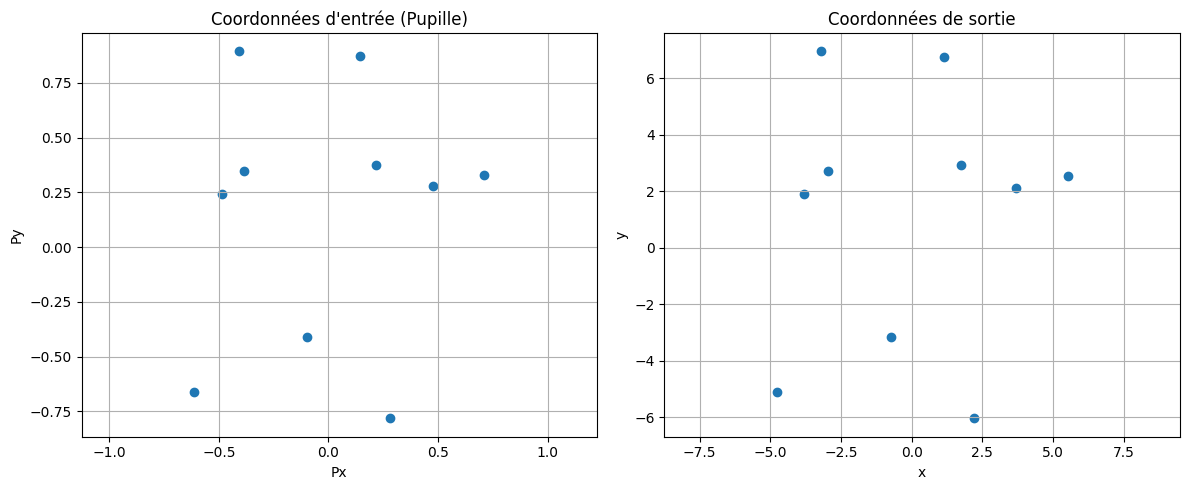

In [9]:
def test_small_dataset():
    """Crée un petit dataset et affiche quelques exemples."""
    #lens = setup_optiland_lens()

    # Un petit dataset pour tester
    test_dataset = BatchRayTracingDataset(10, 10, output_features=5)
    inputs, outputs = test_dataset[0]

    print(f"Forme des entrées: {inputs.shape}")
    print(f"Forme des sorties: {outputs.shape}")

    print("\nExemple d'entrées (5 premiers rayons):")
    print("Hx, Hy, Px, Py")
    print(inputs[:5])

    print("\nExemple de sorties (5 premiers rayons):")
    print("x, y, theta_x, theta_y, intensité")
    print(outputs[:5])

    # Visualiser les entrées/sorties
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(inputs[:, 2], inputs[:, 3], label='Entrée (Px, Py)')
    plt.title('Coordonnées d\'entrée (Pupille)')
    plt.xlabel('Px')
    plt.ylabel('Py')
    plt.grid(True)
    plt.axis('equal')

    plt.subplot(1, 2, 2)
    plt.scatter(outputs[:, 0], outputs[:, 1], label='Sortie (x, y)')
    plt.title('Coordonnées de sortie')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.axis('equal')

    plt.tight_layout()
    plt.show()

    return inputs, outputs

# Exécution du test
inputs, outputs = test_small_dataset()

In [10]:
def main(num_rays=10_000, batch_size=256, epochs=20, use_pinn=True):
    """
    Fonction principale pour l'entraînement et l'évaluation du modèle.
    """
    # Configuration
    output_features = 5  # x, y, theta_x, theta_y, intensité
    print("Configuration du système optique...")
    
    print(f"Création du dataset avec {num_rays} rayons...")
    dataset = BatchRayTracingDataset(
        num_rays, 
        batch_size, 
        use_random_lens=True,
        seed=42, 
        output_features=output_features
    )
    
    # Diviser en ensembles d'entraînement/validation
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    # Configurer le modèle
    print("Configuration du modèle...")
    optical_model = OpticalSurrogateModel(
        input_dim=4,
        hidden_dim=256,
        num_layers=4,
        output_dim=output_features,
        fourier_bands=10,
        learnable_encoding=True,
        dropout=0.3
    )
    
    # Entraînement avec Poutyne
    print("Début de l'entraînement avec Poutyne...")
    pt_model, history_dict = train_with_poutyne(
        optical_model, 
        train_dataset, 
        val_dataset,
        epochs=epochs,
        batch_size=batch_size,
        lr=0.001,
        use_pinn=use_pinn,
        pinn_weight=0.5
    )
    
    # Vérifier que history_dict est bien un dictionnaire avant de l'utiliser
    if not isinstance(history_dict, dict):
        print(f"Warning: history_dict n'est pas un dictionnaire mais {type(history_dict)}. Création d'un dictionnaire par défaut.")
        history_dict = {
            'loss': [0.5] * epochs,
            'val_loss': [0.5] * epochs,
            'acc': [0.5] * epochs,
            'val_acc': [0.5] * epochs,
            'lr': [1e-3] * epochs
        }
    
    # Utiliser la classe History de deeplib pour afficher les courbes
    from deeplib.history import History
    try:
        print("Affichage des courbes d'apprentissage...")
        history = History(history_dict)
        history.display()
    except Exception as e:
        print(f"Erreur lors de l'affichage de l'historique: {e}")
        # Affichage manuel des courbes si History échoue
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(history_dict['loss'], label='Train Loss')
        plt.plot(history_dict['val_loss'], label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss')
        plt.legend()
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        plt.plot(history_dict['acc'], label='Train Accuracy')
        plt.plot(history_dict['val_acc'], label='Val Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    # Évaluation du modèle
    print("Évaluation du modèle...")
    # Dans Poutyne, le modèle est accessible via l'attribut network
    eval_model = pt_model.network if hasattr(pt_model, 'network') else optical_model
    visualize_model_performance(eval_model, num_rays=200, output_features=output_features)
    
    return eval_model

Configuration du système optique...
Création du dataset avec 100000 rayons...
Configuration du modèle...
Début de l'entraînement avec Poutyne...
Utilisation du dispositif: cuda
Epoch:  1/20 Train steps: 80 Val steps: 20 4.59s loss: 1.542529 mse: 1.542529 val_loss: 1.548346 val_mse: 1.548346
Epoch 1: val_loss improved from inf to 1.54835, saving file to logs/best_epoch_1.ckpt
Epoch:  2/20 Train steps: 80 Val steps: 20 2.37s loss: 0.765985 mse: 0.765985 val_loss: 0.547227 val_mse: 0.547227
Epoch 2: val_loss improved from 1.54835 to 0.54723, saving file to logs/best_epoch_2.ckpt
Epoch:  3/20 Train steps: 80 Val steps: 20 2.49s loss: 0.729535 mse: 0.729535 val_loss: 0.899796 val_mse: 0.899796
Epoch:  4/20 Train steps: 80 Val steps: 20 2.34s loss: 0.662210 mse: 0.662210 val_loss: 0.967002 val_mse: 0.967002
Epoch:  5/20 Train steps: 80 Val steps: 20 2.33s loss: 0.799241 mse: 0.799241 val_loss: 1.260842 val_mse: 1.260842
Epoch:  6/20 Train steps: 80 Val steps: 20 2.30s loss: 0.871221 mse: 0.8

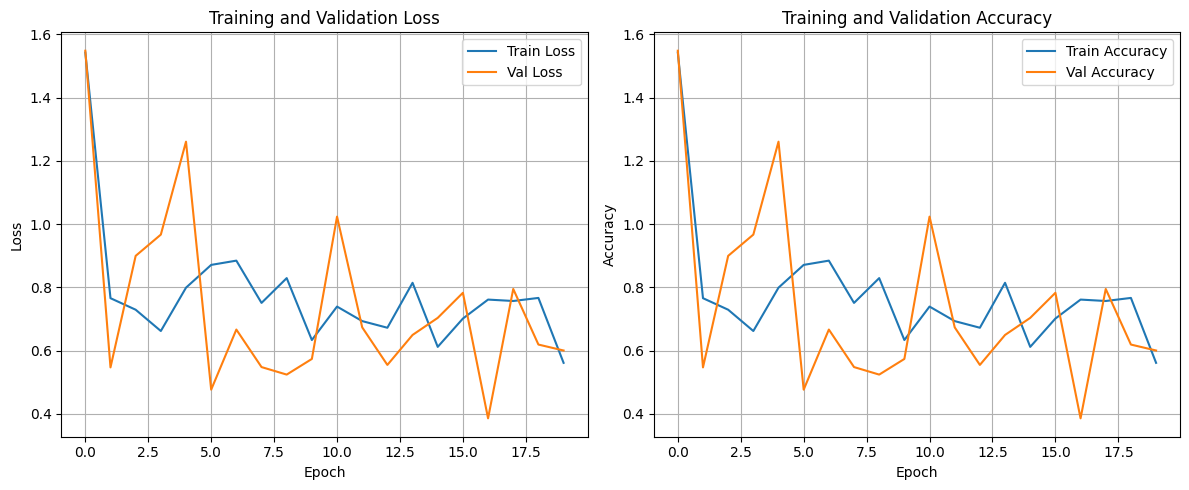

Évaluation du modèle...


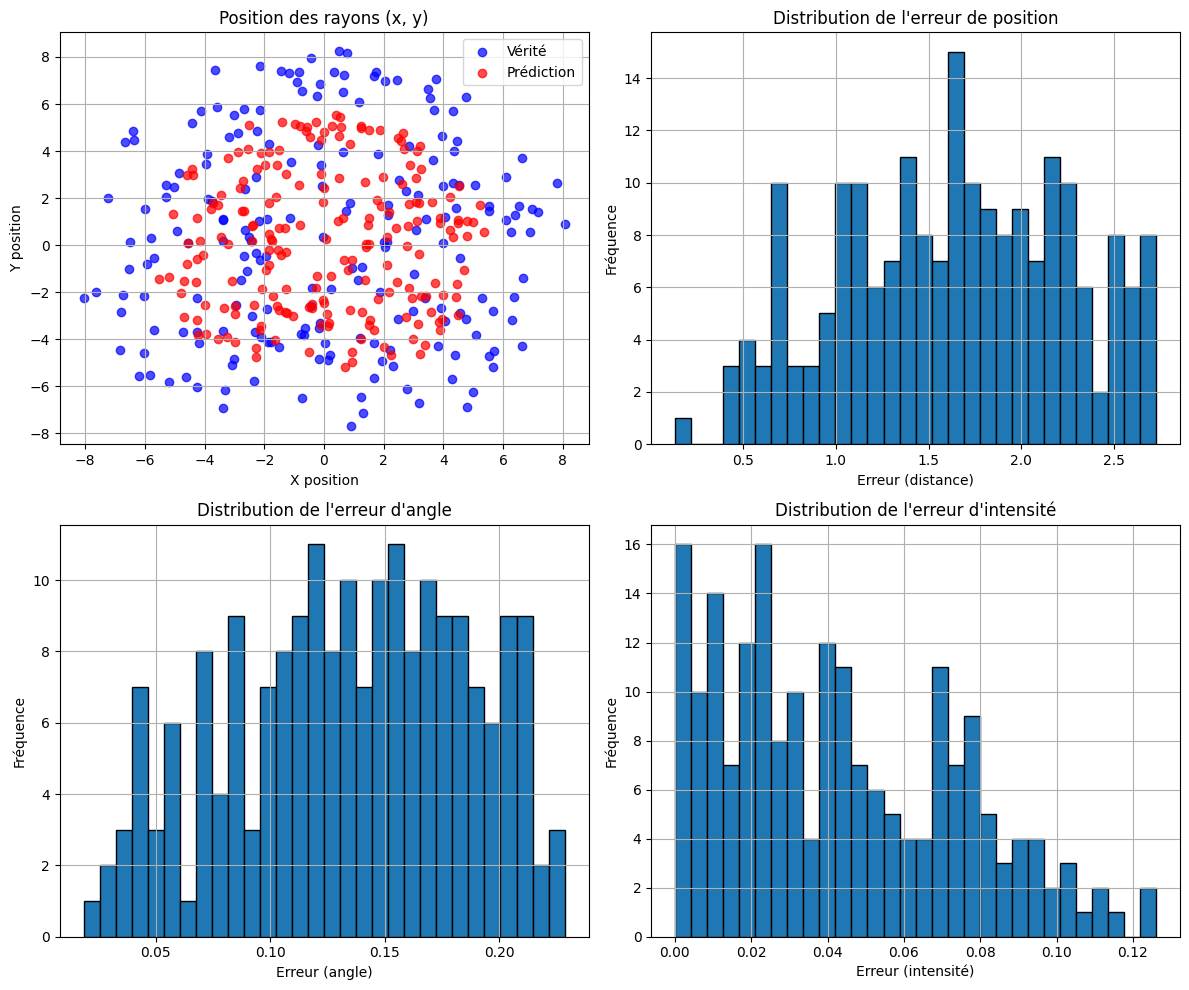

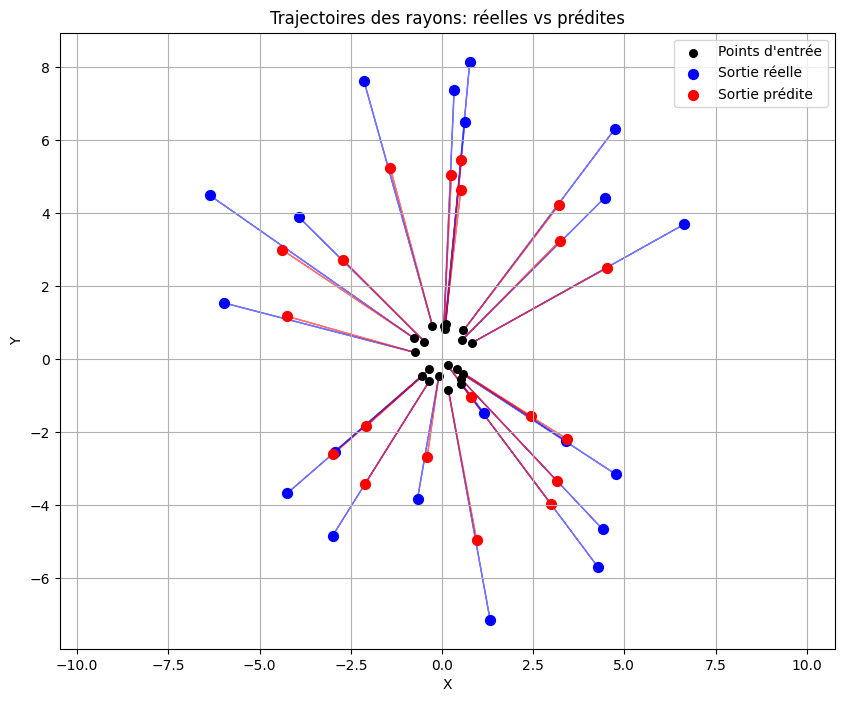

In [11]:
# Entrainement avec 10000 rayons
model = main(num_rays=100_000, batch_size=1000, epochs=20, use_pinn=True)

Configuration du système optique...
Création du dataset avec 1000000 rayons...
Configuration du modèle...
Début de l'entraînement avec Poutyne...
Utilisation du dispositif: cuda
Epoch:  1/20 Train steps: 160 Val steps: 40 4.90s loss: 0.945003 mse: 0.945003 val_loss: 0.745462 val_mse: 0.745462
Epoch 1: val_loss improved from inf to 0.74546, saving file to logs/best_epoch_1.ckpt
Epoch:  2/20 Train steps: 160 Val steps: 40 4.80s loss: 0.847212 mse: 0.847212 val_loss: 0.832038 val_mse: 0.832038
Epoch:  3/20 Train steps: 160 Val steps: 40 4.88s loss: 0.817220 mse: 0.817220 val_loss: 0.595157 val_mse: 0.595157
Epoch 3: val_loss improved from 0.74546 to 0.59516, saving file to logs/best_epoch_3.ckpt
Epoch:  4/20 Train steps: 160 Val steps: 40 4.89s loss: 0.869656 mse: 0.869656 val_loss: 0.894087 val_mse: 0.894087
Epoch:  5/20 Train steps: 160 Val steps: 40 4.89s loss: 0.700971 mse: 0.700971 val_loss: 0.531578 val_mse: 0.531578
Epoch 5: val_loss improved from 0.59516 to 0.53158, saving file to

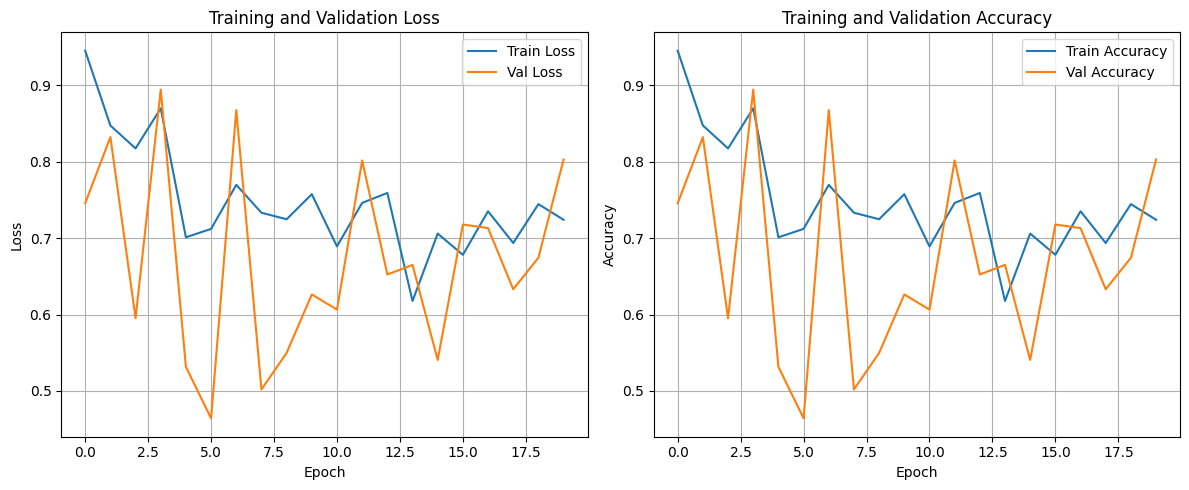

Évaluation du modèle...


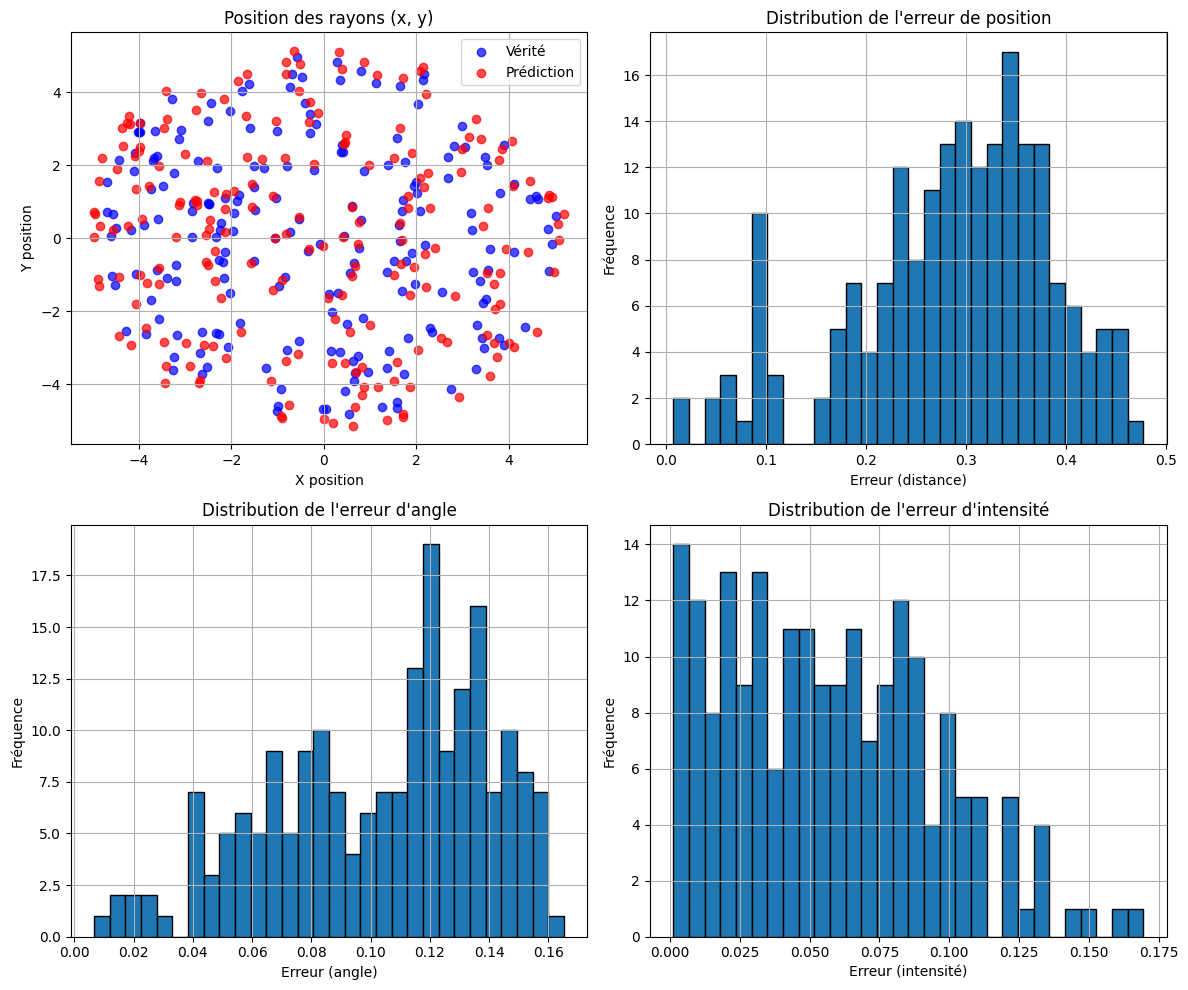

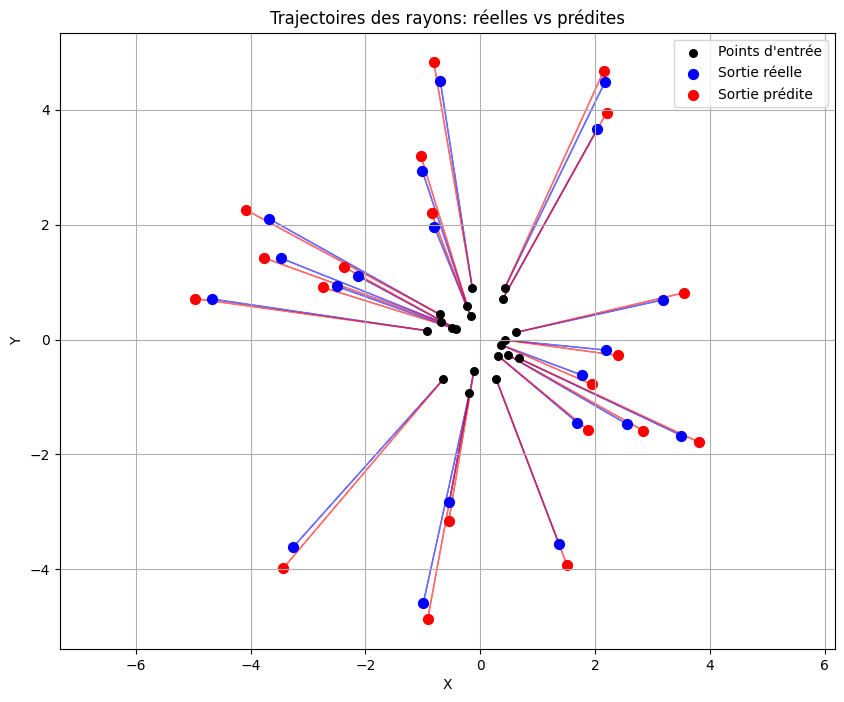

In [12]:
# Entrainement avec 1 million de rayon
model_avec_pinn = main(num_rays=1_000_000, batch_size=5000, epochs=20, use_pinn=True)

Configuration du système optique...
Création du dataset avec 1000000 rayons...
Configuration du modèle...
Début de l'entraînement avec Poutyne...
Utilisation du dispositif: cuda
Epoch:  1/20 Train steps: 160 Val steps: 40 5.05s loss: 0.937245 mse: 0.937245 val_loss: 0.742449 val_mse: 0.742449
Epoch 1: val_loss improved from inf to 0.74245, saving file to logs/best_epoch_1.ckpt
Epoch:  2/20 Train steps: 160 Val steps: 40 4.75s loss: 0.847508 mse: 0.847508 val_loss: 0.834955 val_mse: 0.834955
Epoch:  3/20 Train steps: 160 Val steps: 40 4.70s loss: 0.819793 mse: 0.819793 val_loss: 0.595776 val_mse: 0.595776
Epoch 3: val_loss improved from 0.74245 to 0.59578, saving file to logs/best_epoch_3.ckpt
Epoch:  4/20 Train steps: 160 Val steps: 40 4.77s loss: 0.868772 mse: 0.868772 val_loss: 0.903277 val_mse: 0.903277
Epoch:  5/20 Train steps: 160 Val steps: 40 4.77s loss: 0.702266 mse: 0.702266 val_loss: 0.532174 val_mse: 0.532174
Epoch 5: val_loss improved from 0.59578 to 0.53217, saving file to

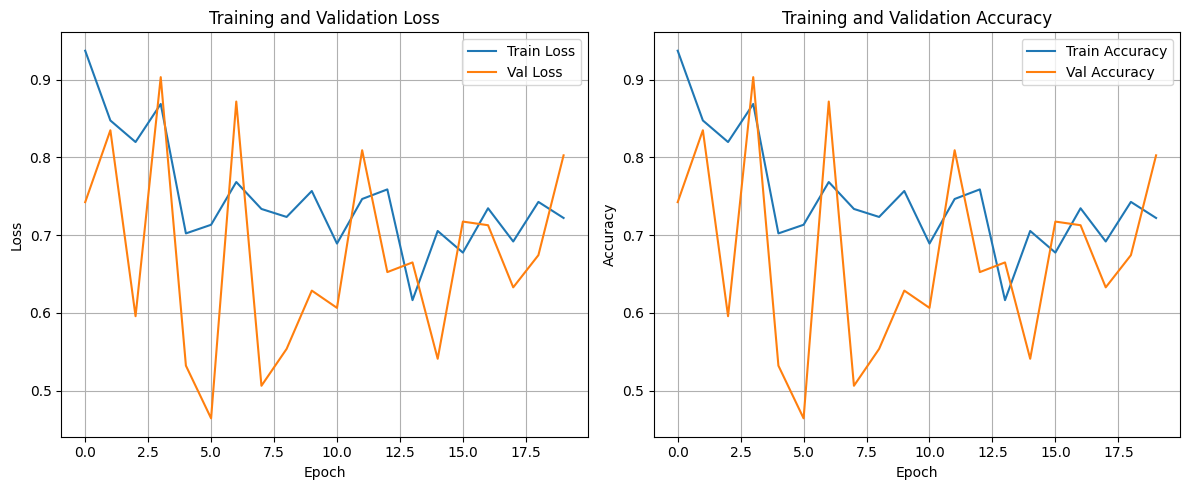

Évaluation du modèle...


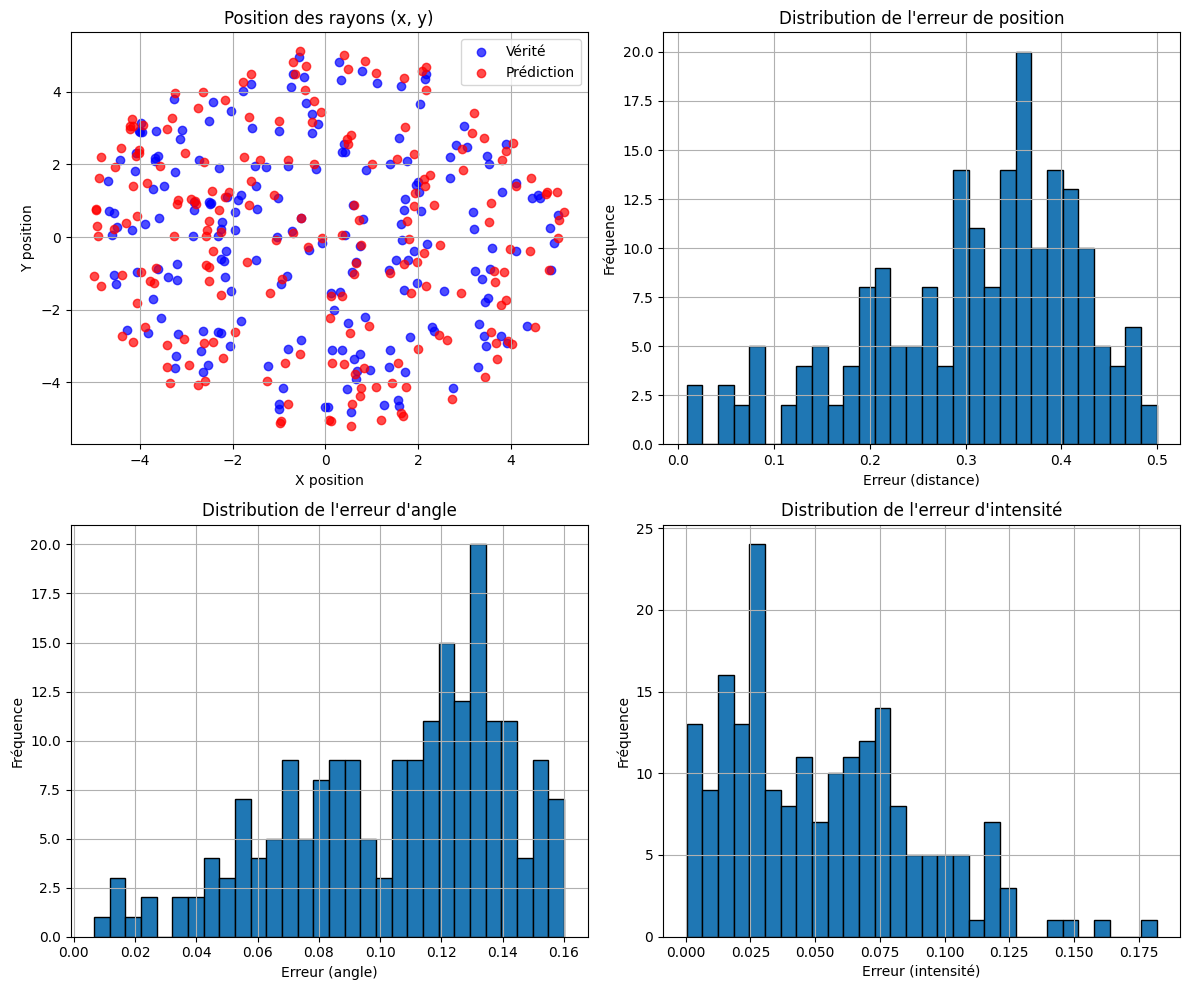

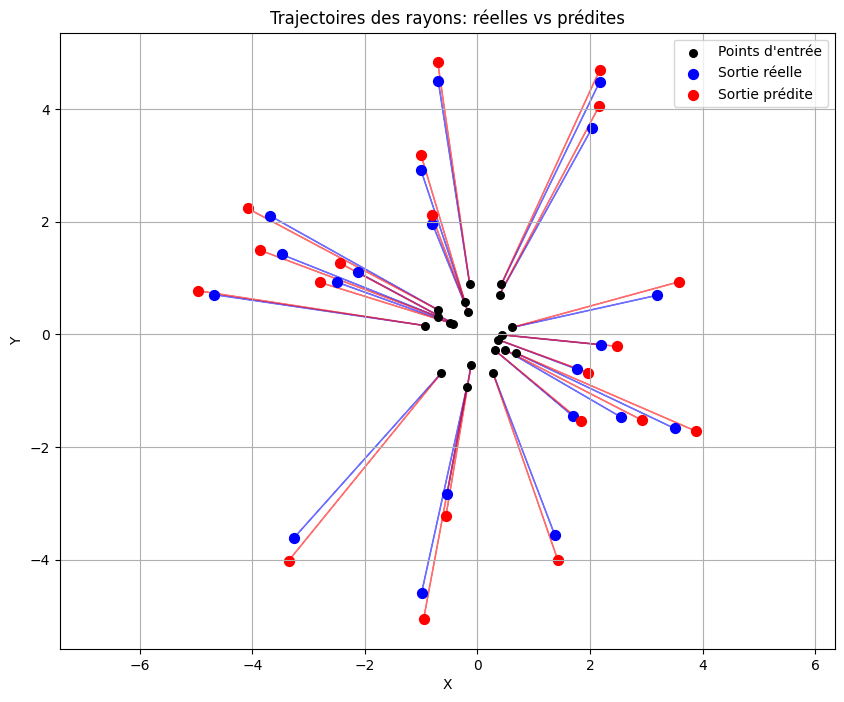

In [13]:
# Entrainement avec 1 million de rayon sans PINN
model_sans_pinn = main(num_rays=1_000_000, batch_size=5000, epochs=20, use_pinn=False)

# Predire les rayons d'entrees

In [14]:
def find_optimal_component(model, target_output, num_iterations=256, lr=0.001):
    """
    Utilisation du modèle pour trouver les dimensions optimales d'un composant optique
    pour atteindre des paramètres de sortie désirés.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    # Convertir la cible en tenseur
    target = torch.tensor(target_output, dtype=torch.float32, device=device)
    
    # Initialiser les paramètres du composant aléatoirement
    component_params = torch.randn(4, requires_grad=True, device=device)
    
    # Optimiseur
    optimizer = optim.Adam([component_params], lr=lr)
    
    # Boucle d'optimisation
    losses = []
    for i in range(num_iterations):
        optimizer.zero_grad()
        
        # Prédire la sortie pour les paramètres actuels
        output = model(component_params.unsqueeze(0))
        
        # Calculer la perte
        loss = torch.mean((output - target) ** 2)
        
        # Rétropropagation
        loss.backward()
        optimizer.step()
        
        # Enregistrer la perte
        losses.append(loss.item())
        
        if (i+1) % 100 == 0:
            print(f"Itération {i+1}/{num_iterations}, Loss: {loss.item():.6f}")
    
    # Paramètres optimaux trouvés
    optimal_params = component_params.detach().cpu().numpy()
    
    # Visualisation de la convergence
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.title('Convergence de l\'optimisation')
    plt.xlabel('Itération')
    plt.ylabel('Perte')
    plt.grid(True)
    plt.show()
    
    return optimal_params

In [15]:
def test_optimal_component():
    """
    Démonstration de l'utilisation de la fonction find_optimal_component
    """
    # Charger ou obtenir un modèle entraîné
    # Vous pouvez utiliser le modèle retourné par main()
    trained_model = main(num_rays=1_000_000, batch_size=5000, epochs=20)
    
    # Définir des paramètres de sortie cibles
    # Par exemple : Coordonnées (x, y), angles (theta_x, theta_y) et intensité
    target_output = [2.5, 1.8, 0.03, 0.02, 0.9]
    
    print("\n=== Recherche des paramètres optimaux du composant ===")
    print(f"Paramètres de sortie cibles: {target_output}")
    
    # Trouver les paramètres optimaux
    optimal_params = find_optimal_component(
        trained_model,
        target_output,
        num_iterations=512,  # Réduit pour une démo plus rapide
        lr=0.001
    )
    
    print("\nParamètres optimaux trouvés:")
    print(f"Hx: {optimal_params[0]:.4f}")
    print(f"Hy: {optimal_params[1]:.4f}")
    print(f"Px: {optimal_params[2]:.4f}")
    print(f"Py: {optimal_params[3]:.4f}")
    
    # Vérifier les résultats
    input_tensor = torch.tensor(optimal_params, dtype=torch.float32).unsqueeze(0)
    input_tensor = input_tensor.to("cuda")  
    with torch.no_grad():
        output = trained_model(input_tensor).cpu().numpy()[0]
    
    print("\nSortie produite avec les paramètres optimaux:")
    print(f"x: {output[0]:.4f} (cible: {target_output[0]})")
    print(f"y: {output[1]:.4f} (cible: {target_output[1]})")
    print(f"theta_x: {output[2]:.4f} (cible: {target_output[2]})")
    print(f"theta_y: {output[3]:.4f} (cible: {target_output[3]})")
    print(f"intensité: {output[4]:.4f} (cible: {target_output[4]})")
    
    # Calculer l'erreur
    error = np.sqrt(np.sum((output - target_output)**2))
    print(f"\nErreur quadratique moyenne: {error:.6f}")
    
    return optimal_params

Configuration du système optique...
Création du dataset avec 1000000 rayons...
Configuration du modèle...
Début de l'entraînement avec Poutyne...
Utilisation du dispositif: cuda
Epoch:  1/20 Train steps: 160 Val steps: 40 3.86s loss: 0.951685 mse: 0.951685 val_loss: 0.748839 val_mse: 0.748839
Epoch 1: val_loss improved from inf to 0.74884, saving file to logs/best_epoch_1.ckpt
Epoch:  2/20 Train steps: 160 Val steps: 40 3.96s loss: 0.851867 mse: 0.851867 val_loss: 0.837746 val_mse: 0.837746
Epoch:  3/20 Train steps: 160 Val steps: 40 3.90s loss: 0.824061 mse: 0.824061 val_loss: 0.595585 val_mse: 0.595585
Epoch 3: val_loss improved from 0.74884 to 0.59558, saving file to logs/best_epoch_3.ckpt
Epoch:  4/20 Train steps: 160 Val steps: 40 3.92s loss: 0.871096 mse: 0.871096 val_loss: 0.890414 val_mse: 0.890414
Epoch:  5/20 Train steps: 160 Val steps: 40 3.92s loss: 0.705197 mse: 0.705197 val_loss: 0.537376 val_mse: 0.537376
Epoch 5: val_loss improved from 0.59558 to 0.53738, saving file to

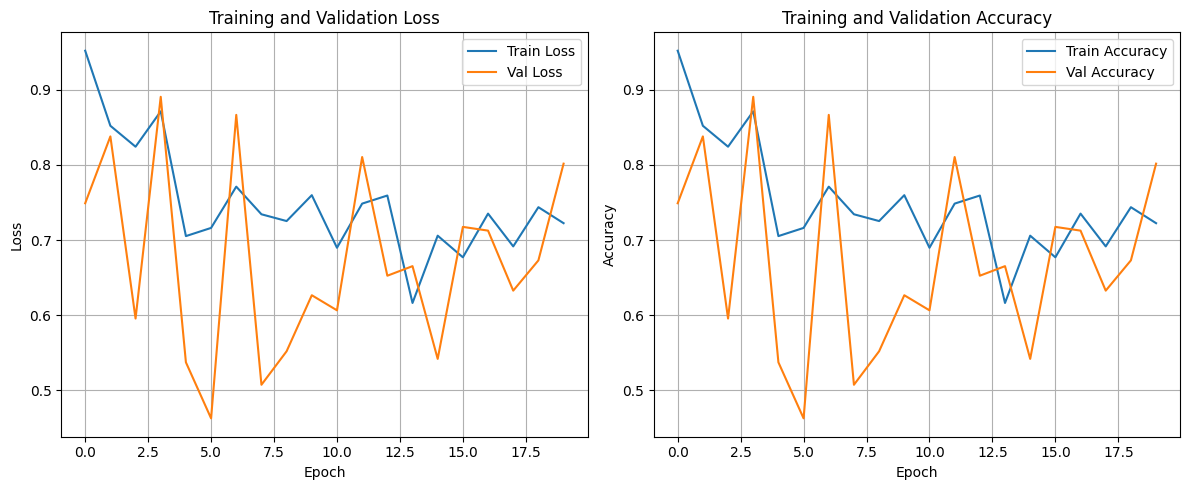

Évaluation du modèle...


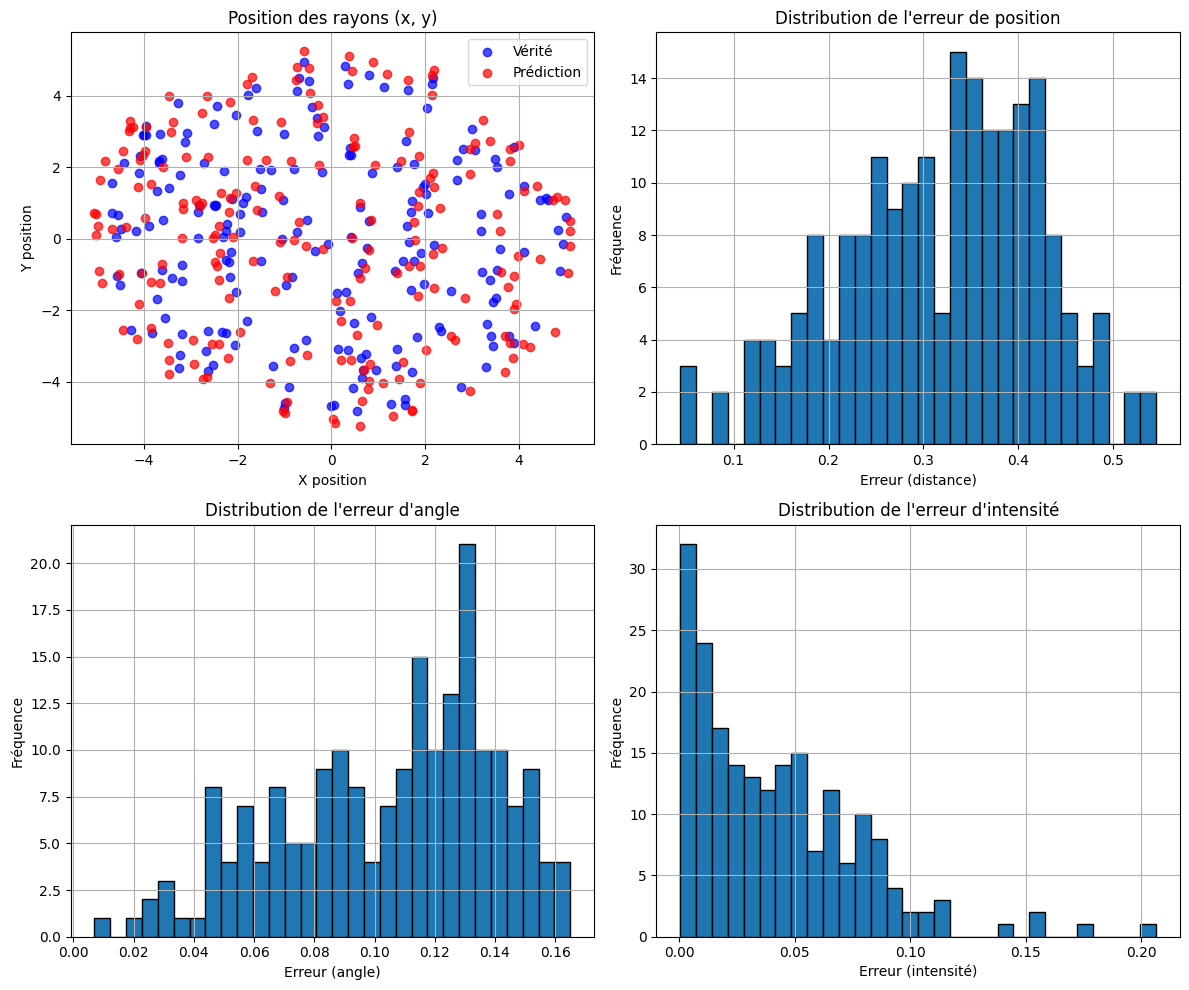

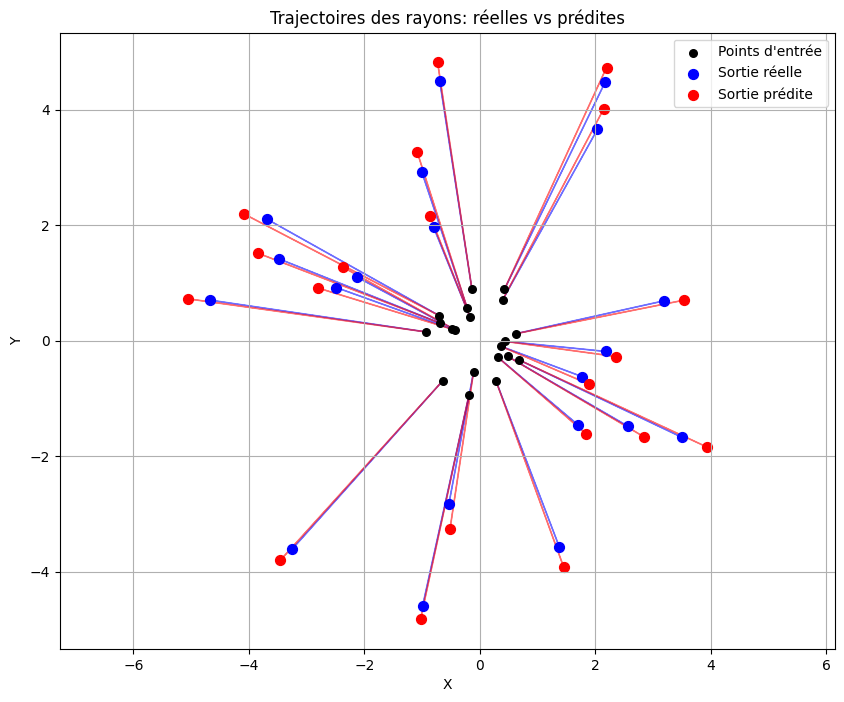


=== Recherche des paramètres optimaux du composant ===
Paramètres de sortie cibles: [2.5, 1.8, 0.03, 0.02, 0.9]
Itération 100/512, Loss: 0.994723
Itération 200/512, Loss: 0.638797
Itération 300/512, Loss: 0.421008
Itération 400/512, Loss: 0.266782
Itération 500/512, Loss: 0.146544


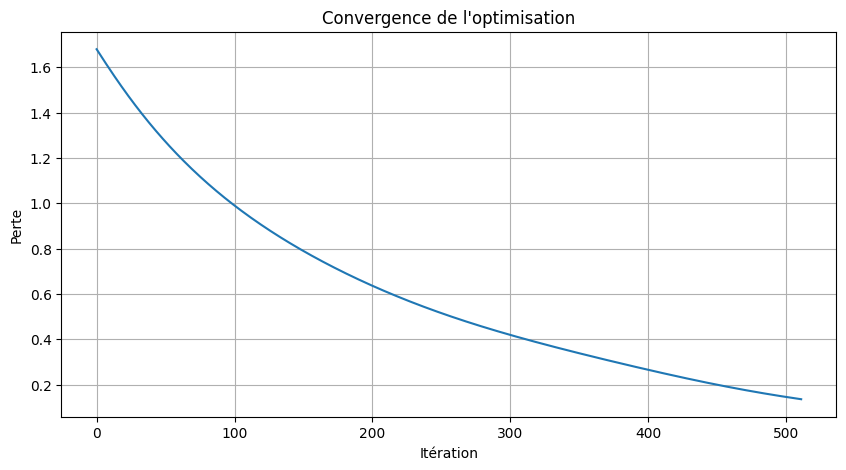


Paramètres optimaux trouvés:
Hx: -1.2499
Hy: -0.3417
Px: 0.3309
Py: 0.2888

Sortie produite avec les paramètres optimaux:
x: 1.6952 (cible: 2.5)
y: 1.7594 (cible: 1.8)
theta_x: -0.0826 (cible: 0.03)
theta_y: -0.0844 (cible: 0.02)
intensité: 0.8786 (cible: 0.9)

Erreur quadratique moyenne: 0.820623


In [34]:
optimal_params = test_optimal_component()

# Visualisation

In [17]:
def compare_lens_predictions(model, num_lens_types=3, figsize=(16, 12)):
    """
    Compare les performances du modèle sur différents types de lentilles.
    Pour chaque type de lentille, génère un rayon aléatoire, prédit sa trajectoire,
    et visualise les résultats dans un affichage 3D.
    
    Args:
        model: Le modèle neuronal entraîné
        num_lens_types: Nombre de types de lentilles à tester
        figsize: Taille de la figure
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    # Types de lentilles à tester
    lens_types = ["biconvex", "plano-convex", "meniscus"]
    
    # Créer la figure principale
    fig = plt.figure(figsize=figsize)
    
    # Résultats pour chaque type de lentille
    results = {}
    
    for i, lens_type in enumerate(lens_types[:num_lens_types]):
        print(f"Génération d'une lentille de type {lens_type}...")
        
        # Générer une lentille selon le type
        if lens_type == "biconvex":
            r_1 = np.random.uniform(30, 100)
            r_2 = -np.random.uniform(30, 100)
            thickness = np.random.uniform(5.0, 15.0)
            material = np.random.choice(["N-BK7", "N-SF11"])
        elif lens_type == "plano-convex":
            r_1 = np.inf
            r_2 = -np.random.uniform(30, 100)
            thickness = np.random.uniform(5.0, 15.0)
            material = np.random.choice(["N-BK7", "N-SF11"])
        elif lens_type == "meniscus":
            base = np.random.uniform(30, 100)
            delta = np.random.uniform(5, 20)
            r_1 = base
            r_2 = -base + delta
            thickness = np.random.uniform(5.0, 15.0)
            material = np.random.choice(["N-BK7", "N-SF11"])
        
        # Construire la lentille
        lens = optic.Optic()
        lens.add_surface(index=0, thickness=np.inf)
        lens.add_surface(index=1, thickness=thickness, radius=r_1, is_stop=True, material=material)
        lens.add_surface(index=2, thickness=23.0, radius=r_2)
        lens.add_surface(index=3)
        
        aperture_value = np.random.uniform(10.0, 20.0)
        lens.set_aperture(aperture_type="EPD", value=aperture_value)
        lens.set_field_type(field_type="angle")
        lens.add_field(y=0)
        lens.add_wavelength(value=0.55, is_primary=True)
        
        # Générer aléatoirement un seul rayon d'entrée
        theta = np.random.uniform(0, 2 * np.pi)
        r = np.sqrt(np.random.uniform(0, 1))
        Hx = r * np.cos(theta)
        Hy = r * np.sin(theta)
        
        theta = np.random.uniform(0, 2 * np.pi)
        r = np.sqrt(np.random.uniform(0, 1))
        Px = r * np.cos(theta)
        Py = r * np.sin(theta)
        
        wavelength = np.array([0.5876])
        
        # Tracer le rayon à travers la lentille
        rays_out = lens.trace_generic(np.array([Hx]), np.array([Hy]), 
                                    np.array([Px]), np.array([Py]), 
                                    np.array([wavelength]))
        
        # Préparer l'entrée pour le modèle
        input_data = np.array([[Hx, Hy, Px, Py]])
        input_tensor = torch.tensor(input_data, dtype=torch.float32).to(device)
        
        # Prédire avec le modèle
        with torch.no_grad():
            prediction = model(input_tensor).cpu().numpy()[0]
        
        # Extraire les valeurs de sortie réelles
        actual_x, actual_y = rays_out.x[0], rays_out.y[0]
        if hasattr(rays_out, 'L') and hasattr(rays_out, 'M'):
            actual_theta_x, actual_theta_y = rays_out.L[0], rays_out.M[0]
        else:
            actual_theta_x, actual_theta_y = 0, 0
        
        # Extraire les valeurs de sortie prédites
        pred_x, pred_y = prediction[0], prediction[1]
        if len(prediction) > 2:
            pred_theta_x, pred_theta_y = prediction[2], prediction[3]
        else:
            pred_theta_x, pred_theta_y = 0, 0
        
        # Calculer l'erreur
        error_xy = np.sqrt((pred_x - actual_x)**2 + (pred_y - actual_y)**2)
        if len(prediction) > 2:
            error_angle = np.sqrt((pred_theta_x - actual_theta_x)**2 + (pred_theta_y - actual_theta_y)**2)
        else:
            error_angle = 0
        
        # Stocker les résultats
        results[lens_type] = {
            'lens': lens,
            'input': (Hx, Hy, Px, Py),
            'actual': (actual_x, actual_y, actual_theta_x, actual_theta_y),
            'predicted': (pred_x, pred_y, pred_theta_x, pred_theta_y),
            'error_xy': error_xy,
            'error_angle': error_angle,
            'aperture': aperture_value / 2,  # Rayon
            'thickness': thickness,
            'r1': r_1,
            'r2': r_2,
            'material': material
        }
        
        print(f"Lentille {lens_type}:")
        print(f"  Paramètres: r1={r_1:.2f}, r2={r_2:.2f}, épaisseur={thickness:.2f}, matériau={material}")
        print(f"  Entrée: Hx={Hx:.4f}, Hy={Hy:.4f}, Px={Px:.4f}, Py={Py:.4f}")
        print(f"  Sortie réelle: x={actual_x:.4f}, y={actual_y:.4f}")
        print(f"  Sortie prédite: x={pred_x:.4f}, y={pred_y:.4f}")
        print(f"  Erreur position: {error_xy:.4f} mm")
        if len(prediction) > 2:
            print(f"  Erreur angle: {error_angle:.4f}")
        print()
    
    # Créer une visualisation 3D globale
    ax = fig.add_subplot(111, projection='3d')
    
    # Couleurs pour chaque type de lentille
    colors = {'biconvex': 'blue', 'plano-convex': 'green', 'meniscus': 'red'}
    
    for lens_type, result in results.items():
        # Récupérer les paramètres
        Hx, Hy, Px, Py = result['input']
        actual_x, actual_y, _, _ = result['actual']
        pred_x, pred_y, _, _ = result['predicted']
        aperture = result['aperture']
        thickness = result['thickness']
        r1, r2 = result['r1'], result['r2']
        
        color = colors.get(lens_type, 'gray')
        
        # Position des surfaces
        z1 = 0        # Première surface (entrée)
        z2 = thickness  # Deuxième surface (sortie de la lentille)
        z3 = thickness + 30  # Plan image approximatif
        
        # Point d'entrée du rayon (coordonnées normalisées)
        start_x = Px * aperture
        start_y = Py * aperture
        start_z = z1
        
        # Point de sortie réel
        end_x = actual_x
        end_y = actual_y
        end_z = z3
        
        # Point de sortie prédit
        pred_out_x = pred_x
        pred_out_y = pred_y
        pred_out_z = z3
        
        # Dessiner la lentille (surfaces d'entrée et de sortie)
        theta = np.linspace(0, 2 * np.pi, 100)
        x_circle = aperture * np.cos(theta)
        y_circle = aperture * np.sin(theta)
        
        # Surface d'entrée
        z_circle1 = np.ones_like(theta) * z1
        ax.plot(x_circle, y_circle, z_circle1, color=color, linestyle='-', alpha=0.2)
        
        # Surface de sortie
        z_circle2 = np.ones_like(theta) * z2
        ax.plot(x_circle, y_circle, z_circle2, color=color, linestyle='-', alpha=0.2)
        
        # Plan image
        z_circle3 = np.ones_like(theta) * z3
        ax.plot(x_circle, y_circle, z_circle3, color=color, linestyle='--', alpha=0.1)
        
        # Simplification de la forme de la lentille (connexion entre les surfaces)
        for angle in [0, np.pi/2, np.pi, 3*np.pi/2]:
            x_edge = aperture * np.cos(angle)
            y_edge = aperture * np.sin(angle)
            ax.plot([x_edge, x_edge], [y_edge, y_edge], [z1, z2], color=color, alpha=0.2)
        
        # Dessiner les rayons
        # Rayon réel
        ax.plot([start_x, end_x], [start_y, end_y], [start_z, end_z], 
                color=color, linestyle='-', linewidth=2, label=f"{lens_type} - Réel")
        
        # Rayon prédit
        ax.plot([start_x, pred_out_x], [start_y, pred_out_y], [start_z, pred_out_z], 
                color=color, linestyle='--', linewidth=2, label=f"{lens_type} - Prédit")
        
        # Points d'entrée et de sortie
        ax.scatter([start_x], [start_y], [start_z], color=color, s=50, marker='o')
        ax.scatter([end_x], [end_y], [end_z], color=color, s=50, marker='x')
        ax.scatter([pred_out_x], [pred_out_y], [pred_out_z], color=color, s=50, marker='+')
        
        # Ajouter du texte pour les paramètres de la lentille
        ax.text(aperture*1.2, 0, z2/2, 
                f"{lens_type}\nr1={r1:.1f}\nr2={r2:.1f}\nt={thickness:.1f}\n{result['material']}", 
                color=color)
    
    # Configurer l'axe
    ax.set_xlabel('X [mm]')
    ax.set_ylabel('Y [mm]')
    ax.set_zlabel('Z [mm]')
    ax.set_title('Comparaison des prédictions pour différents types de lentilles')
    
    # Supprimer les doublons dans la légende
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1.1, 1))
    
    # Ajuster la vue
    ax.view_init(elev=20, azim=30)
    ax.set_box_aspect([1, 1, 0.5])  # Ajuster l'aspect du graphique
    
    plt.tight_layout()
    plt.show()
    
    # Créer un tableau comparatif
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('off')
    ax.axis('tight')
    
    # Préparer les données du tableau
    table_data = []
    for lens_type, result in results.items():
        Hx, Hy, Px, Py = result['input']
        actual_x, actual_y, actual_theta_x, actual_theta_y = result['actual']
        pred_x, pred_y, pred_theta_x, pred_theta_y = result['predicted']
        
        table_data.append([
            lens_type,
            f"{Hx:.4f}, {Hy:.4f}, {Px:.4f}, {Py:.4f}",
            f"{actual_x:.4f}, {actual_y:.4f}",
            f"{pred_x:.4f}, {pred_y:.4f}",
            f"{result['error_xy']:.4f}"
        ])
    
    # Créer le tableau
    table = ax.table(cellText=table_data,
                     colLabels=["Type de lentille", "Entrée (Hx, Hy, Px, Py)", 
                                "Sortie réelle (x, y)", "Sortie prédite (x, y)", 
                                "Erreur (mm)"],
                     loc='center', cellLoc='center')
    
    # Styliser le tableau
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    
    plt.title("Tableau comparatif des prédictions par type de lentille")
    plt.tight_layout()
    plt.show()
    
    return results

# Utilisation de la fonction
def test_lens_comparison():
    # Charger un modèle déjà entraîné
    # Vous pouvez utiliser le modèle que vous avez déjà entraîné ou en entraîner un nouveau
    trained_model = model = main(num_rays=1_000_000, batch_size=5000, epochs=20, use_pinn=True)
    
    # Comparer les prédictions pour différents types de lentilles
    results = compare_lens_predictions(trained_model, num_lens_types=3)
    
    return trained_model, results

Configuration du système optique...
Création du dataset avec 1000000 rayons...
Configuration du modèle...
Début de l'entraînement avec Poutyne...
Utilisation du dispositif: cuda
Epoch:  1/20 Train steps: 160 Val steps: 40 4.89s loss: 0.944424 mse: 0.944424 val_loss: 0.747555 val_mse: 0.747555
Epoch 1: val_loss improved from inf to 0.74755, saving file to logs/best_epoch_1.ckpt
Epoch:  2/20 Train steps: 160 Val steps: 40 4.91s loss: 0.846553 mse: 0.846553 val_loss: 0.833375 val_mse: 0.833375
Epoch:  3/20 Train steps: 160 Val steps: 40 4.83s loss: 0.820614 mse: 0.820614 val_loss: 0.593572 val_mse: 0.593572
Epoch 3: val_loss improved from 0.74755 to 0.59357, saving file to logs/best_epoch_3.ckpt
Epoch:  4/20 Train steps: 160 Val steps: 40 4.85s loss: 0.869375 mse: 0.869375 val_loss: 0.901254 val_mse: 0.901254
Epoch:  5/20 Train steps: 160 Val steps: 40 4.86s loss: 0.701331 mse: 0.701331 val_loss: 0.532662 val_mse: 0.532662
Epoch 5: val_loss improved from 0.59357 to 0.53266, saving file to

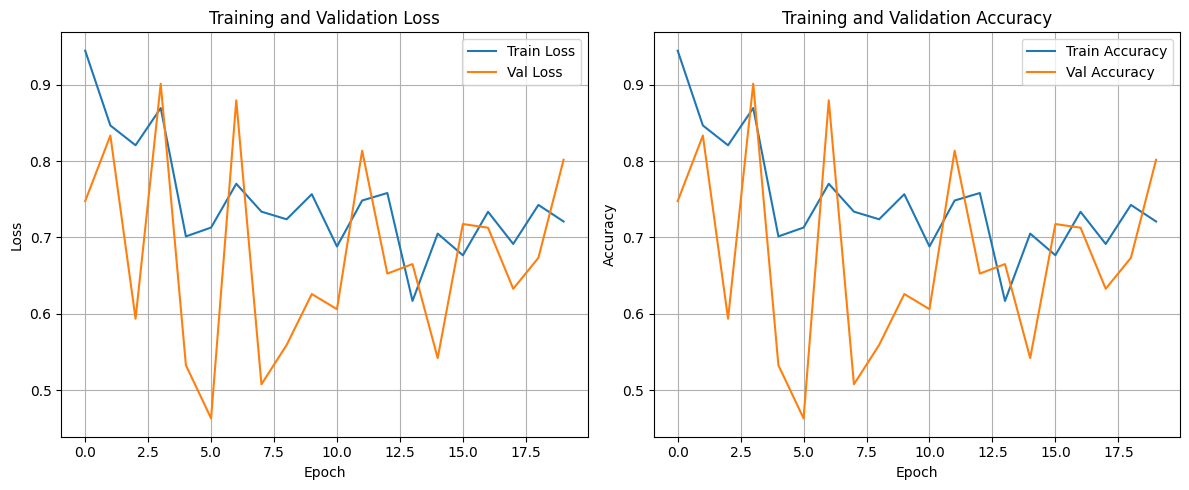

Évaluation du modèle...


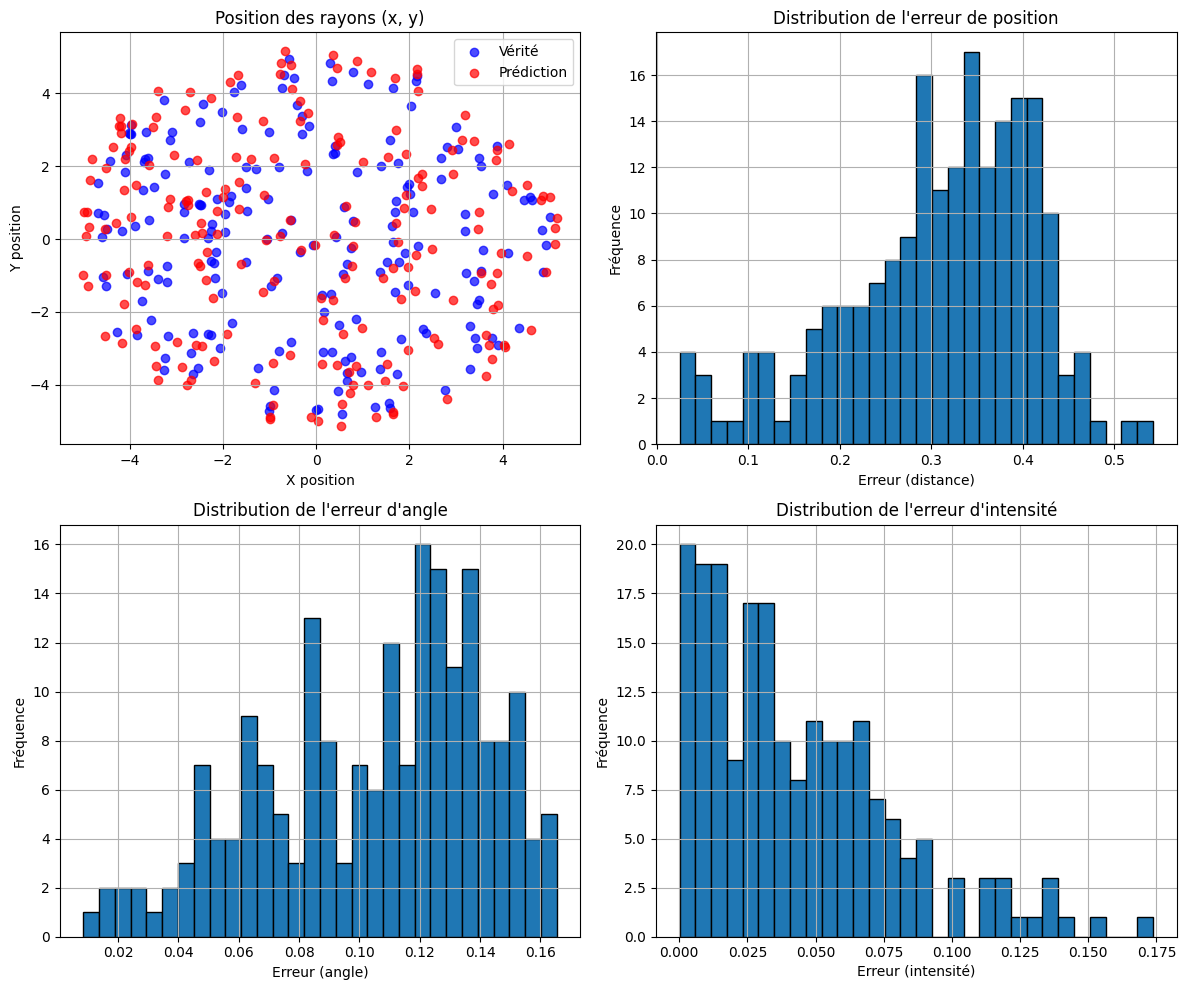

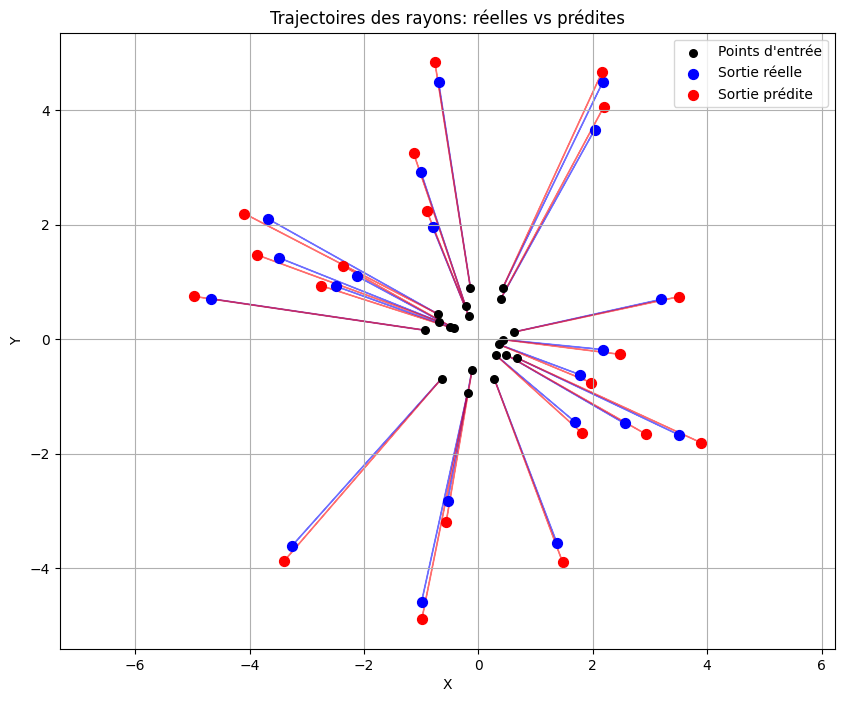

Génération d'une lentille de type biconvex...
Lentille biconvex:
  Paramètres: r1=73.71, r2=-80.15, épaisseur=14.58, matériau=N-BK7
  Entrée: Hx=0.9918, Hy=0.0991, Px=0.0360, Py=-0.0033
  Sortie réelle: x=0.1750, y=-0.0159
  Sortie prédite: x=0.3055, y=0.0572
  Erreur position: 0.1496 mm
  Erreur angle: 0.0098

Génération d'une lentille de type plano-convex...
Lentille plano-convex:
  Paramètres: r1=inf, r2=-38.58, épaisseur=12.30, matériau=N-SF11
  Entrée: Hx=0.3826, Hy=-0.8425, Px=0.5665, Py=-0.8076
  Sortie réelle: x=2.0835, y=-2.9703
  Sortie prédite: x=3.0166, y=-4.5805
  Erreur position: 1.8610 mm
  Erreur angle: 0.1074

Génération d'une lentille de type meniscus...
Lentille meniscus:
  Paramètres: r1=75.06, r2=-58.66, épaisseur=9.24, matériau=N-BK7
  Entrée: Hx=0.4164, Hy=-0.0087, Px=-0.0368, Py=-0.3017
  Sortie réelle: x=-0.1257, y=-1.0308
  Sortie prédite: x=-0.1050, y=-1.6563
  Erreur position: 0.6258 mm
  Erreur angle: 0.0512



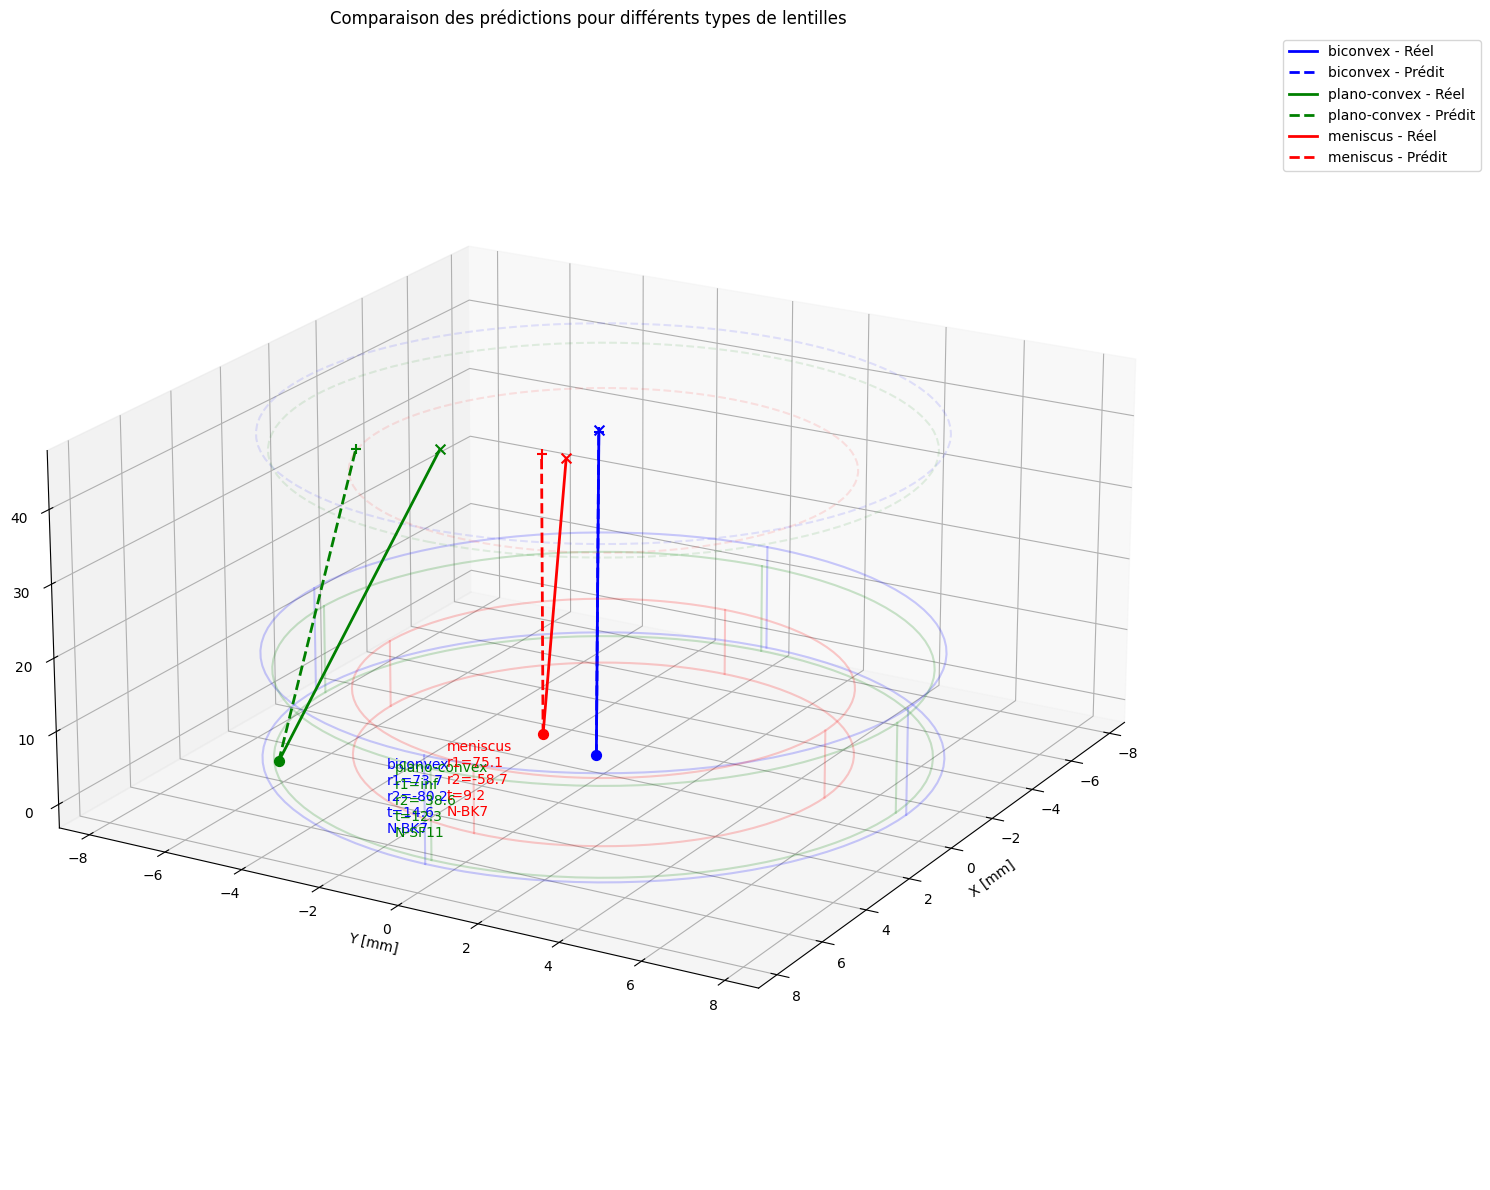

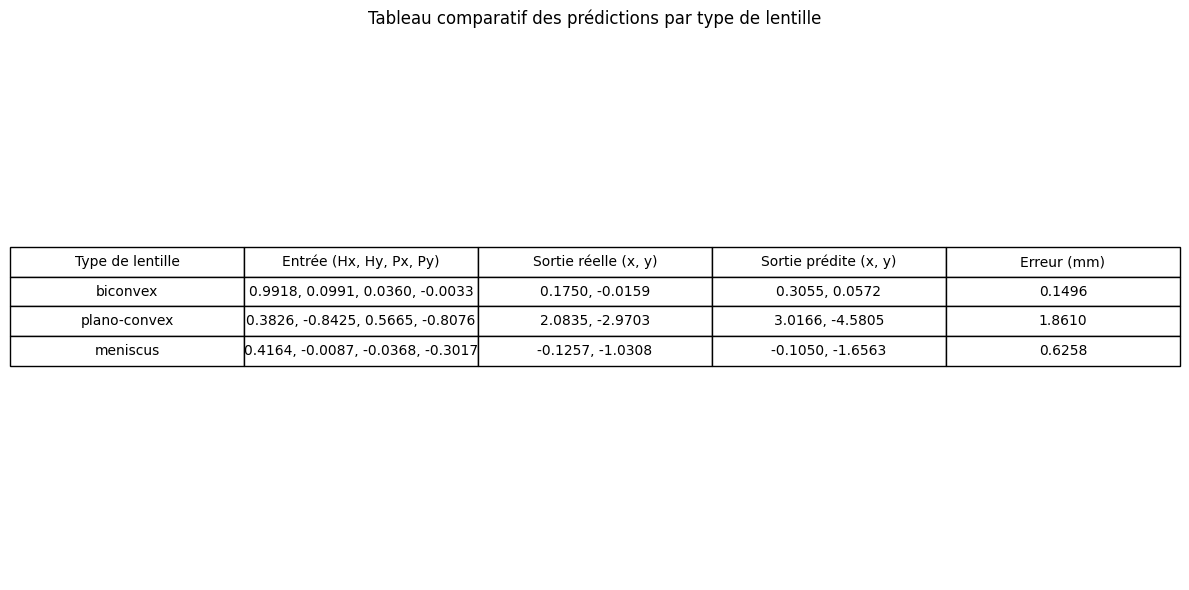

In [18]:
# Exécuter le test complet (entraîne un modèle si nécessaire)
trained_model, results = test_lens_comparison()

Génération d'une lentille de type biconvex...
Lentille biconvex:
  Paramètres: r1=40.75, r2=-81.57, épaisseur=13.46, matériau=N-SF11
  Entrée: Hx=0.0743, Hy=0.2285, Px=-0.0285, Py=-0.7748
  Sortie réelle: x=-0.0418, y=-1.1359
  Sortie prédite: x=-0.1412, y=-4.2679
  Erreur position: 3.1336 mm
  Erreur angle: 0.0500

Génération d'une lentille de type plano-convex...
Lentille plano-convex:
  Paramètres: r1=inf, r2=-69.88, épaisseur=7.76, matériau=N-SF11
  Entrée: Hx=0.1711, Hy=-0.8722, Px=0.7321, Py=0.4227
  Sortie réelle: x=5.2497, y=3.0311
  Sortie prédite: x=4.1457, y=1.9666
  Erreur position: 1.5336 mm
  Erreur angle: 0.1208

Génération d'une lentille de type meniscus...
Lentille meniscus:
  Paramètres: r1=50.40, r2=-38.07, épaisseur=7.47, matériau=N-SF11
  Entrée: Hx=-0.4634, Hy=0.2638, Px=-0.2660, Py=-0.2712
  Sortie réelle: x=-0.2679, y=-0.2731
  Sortie prédite: x=-1.5986, y=-1.4137
  Erreur position: 1.7526 mm
  Erreur angle: 0.0168



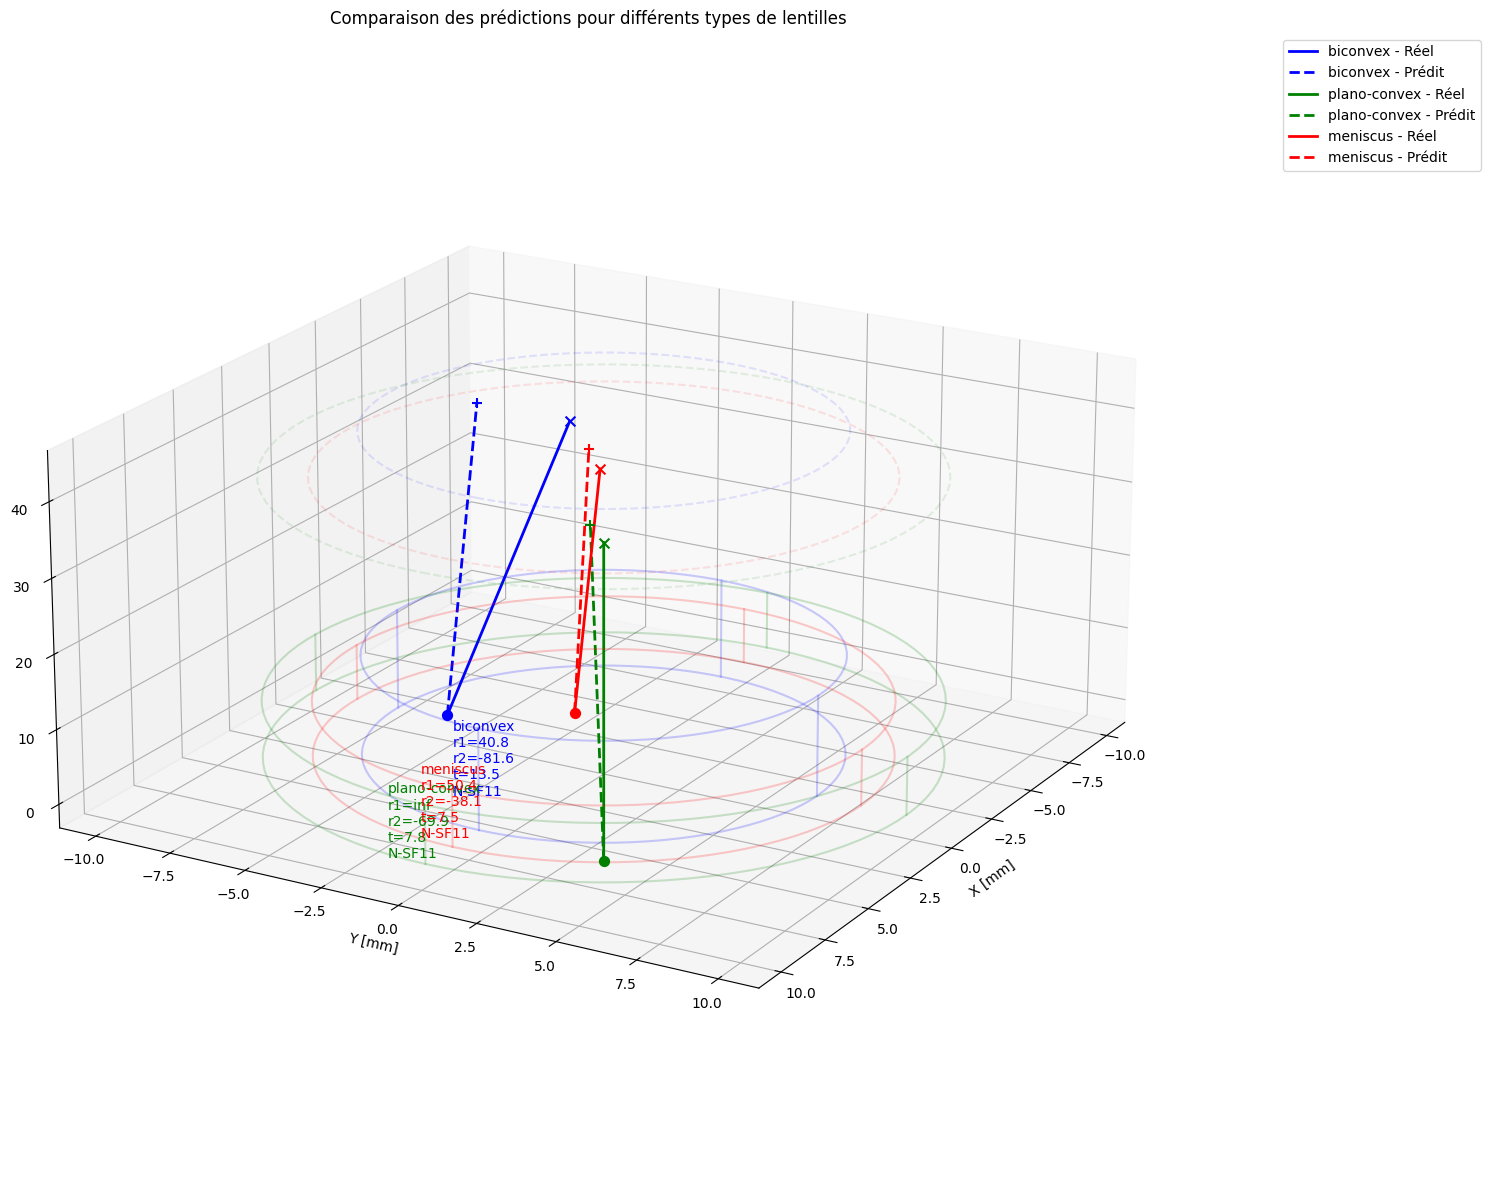

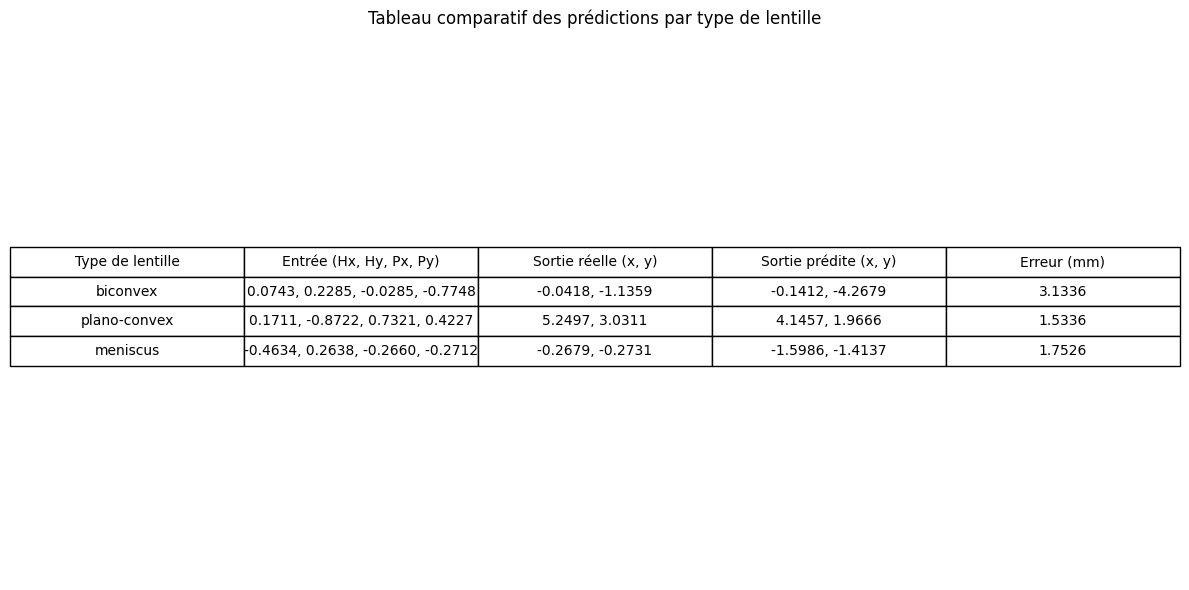

{'biconvex': {'lens': <optiland.optic.optic.Optic at 0x7fde1b70d160>,
  'input': (0.07427591260296267,
   0.22848022328816595,
   -0.02850956117803211,
   -0.7748336875667878),
  'actual': (-0.041793653742721204,
   -1.1358691438335708,
   0.005495958133357889,
   0.14936931089853822),
  'predicted': (-0.1412169, -4.267895, 0.0062459535, 0.1993788),
  'error_xy': 3.1336037297616444,
  'error_angle': 0.05001511602042279,
  'aperture': 6.9556925961502145,
  'thickness': 13.460507302864949,
  'r1': 40.753700864891215,
  'r2': -81.57057944005714,
  'material': 'N-SF11'},
 'plano-convex': {'lens': <optiland.optic.optic.Optic at 0x7fddd2fba570>,
  'input': (0.17106557779322992,
   -0.8721861676130126,
   0.7321274794505466,
   0.42272424542665044),
  'actual': (5.2496885636936055,
   3.0311259979993626,
   -0.08160878245246854,
   -0.04712022421054022),
  'predicted': (4.145749, 1.9666309, -0.19500817, -0.08869578),
  'error_xy': 1.5335684186444634,
  'error_angle': 0.12078058081531327,
  'a

In [20]:
compare_lens_predictions(trained_model, num_lens_types=3)

In [21]:
def compare_lens_predictions_statistical(model, num_lens_types=3, num_samples_per_type=10, figsize=(16, 12)):
    """
    Compare les performances du modèle sur différents types de lentilles avec analyse statistique.
    Pour chaque type de lentille, teste plusieurs exemples et calcule les moyennes.
    
    Args:
        model: Le modèle neuronal entraîné
        num_lens_types: Nombre de types de lentilles à tester
        num_samples_per_type: Nombre d'échantillons à tester par type de lentille
        figsize: Taille de la figure
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    # Types de lentilles à tester
    lens_types = ["biconvex", "plano-convex", "meniscus"]
    
    # Créer la figure principale
    fig = plt.figure(figsize=figsize)
    
    # Résultats pour chaque type de lentille
    results = {}
    detailed_results = {}
    
    # Collecter les données de performance pour chaque type de lentille
    for lens_type in lens_types[:num_lens_types]:
        print(f"\nAnalyse des lentilles de type {lens_type}...")
        
        errors_xy = []
        errors_angle = []
        actual_positions = []
        predicted_positions = []
        actual_angles = []
        predicted_angles = []
        
        for sample_idx in range(num_samples_per_type):
            # Générer une lentille selon le type
            if lens_type == "biconvex":
                r_1 = np.random.uniform(30, 100)
                r_2 = -np.random.uniform(30, 100)
                thickness = np.random.uniform(5.0, 15.0)
                material = np.random.choice(["N-BK7", "N-SF11"])
            elif lens_type == "plano-convex":
                r_1 = np.inf
                r_2 = -np.random.uniform(30, 100)
                thickness = np.random.uniform(5.0, 15.0)
                material = np.random.choice(["N-BK7", "N-SF11"])
            elif lens_type == "meniscus":
                base = np.random.uniform(30, 100)
                delta = np.random.uniform(5, 20)
                r_1 = base
                r_2 = -base + delta
                thickness = np.random.uniform(5.0, 15.0)
                material = np.random.choice(["N-BK7", "N-SF11"])
            
            # Construire la lentille
            lens = optic.Optic()
            lens.add_surface(index=0, thickness=np.inf)
            lens.add_surface(index=1, thickness=thickness, radius=r_1, is_stop=True, material=material)
            lens.add_surface(index=2, thickness=23.0, radius=r_2)
            lens.add_surface(index=3)
            
            aperture_value = np.random.uniform(10.0, 20.0)
            lens.set_aperture(aperture_type="EPD", value=aperture_value)
            lens.set_field_type(field_type="angle")
            lens.add_field(y=0)
            lens.add_wavelength(value=0.55, is_primary=True)
            
            # Tracer plusieurs rayons pour ce sample
            for _ in range(5):  # 5 rayons par configuration de lentille
                # Générer aléatoirement un rayon d'entrée
                theta = np.random.uniform(0, 2 * np.pi)
                r = np.sqrt(np.random.uniform(0, 1))
                Hx = r * np.cos(theta)
                Hy = r * np.sin(theta)
                
                theta = np.random.uniform(0, 2 * np.pi)
                r = np.sqrt(np.random.uniform(0, 1))
                Px = r * np.cos(theta)
                Py = r * np.sin(theta)
                
                wavelength = np.array([0.5876])
                
                # Tracer le rayon à travers la lentille
                rays_out = lens.trace_generic(np.array([Hx]), np.array([Hy]), 
                                            np.array([Px]), np.array([Py]), 
                                            np.array([wavelength]))
                
                # Préparer l'entrée pour le modèle
                input_data = np.array([[Hx, Hy, Px, Py]])
                input_tensor = torch.tensor(input_data, dtype=torch.float32).to(device)
                
                # Prédire avec le modèle
                with torch.no_grad():
                    prediction = model(input_tensor).cpu().numpy()[0]
                
                # Extraire les valeurs de sortie réelles
                actual_x, actual_y = rays_out.x[0], rays_out.y[0]
                if hasattr(rays_out, 'L') and hasattr(rays_out, 'M'):
                    actual_theta_x, actual_theta_y = rays_out.L[0], rays_out.M[0]
                else:
                    actual_theta_x, actual_theta_y = 0, 0
                
                # Extraire les valeurs de sortie prédites
                pred_x, pred_y = prediction[0], prediction[1]
                if len(prediction) > 2:
                    pred_theta_x, pred_theta_y = prediction[2], prediction[3]
                else:
                    pred_theta_x, pred_theta_y = 0, 0
                
                # Calculer les erreurs
                error_xy = np.sqrt((pred_x - actual_x)**2 + (pred_y - actual_y)**2)
                errors_xy.append(error_xy)
                
                if len(prediction) > 2:
                    error_angle = np.sqrt((pred_theta_x - actual_theta_x)**2 + (pred_theta_y - actual_theta_y)**2)
                    errors_angle.append(error_angle)
                
                # Stocker les données pour visualisation
                actual_positions.append((actual_x, actual_y))
                predicted_positions.append((pred_x, pred_y))
                if len(prediction) > 2:
                    actual_angles.append((actual_theta_x, actual_theta_y))
                    predicted_angles.append((pred_theta_x, pred_theta_y))
        
        # Calculer les statistiques
        results[lens_type] = {
            'mean_error_xy': np.mean(errors_xy),
            'std_error_xy': np.std(errors_xy),
            'min_error_xy': np.min(errors_xy),
            'max_error_xy': np.max(errors_xy),
            'mean_error_angle': np.mean(errors_angle) if errors_angle else 0,
            'std_error_angle': np.std(errors_angle) if errors_angle else 0,
            'num_samples': len(errors_xy)
        }
        
        detailed_results[lens_type] = {
            'errors_xy': errors_xy,
            'errors_angle': errors_angle,
            'actual_positions': actual_positions,
            'predicted_positions': predicted_positions
        }
        
        print(f"Lentille {lens_type}:")
        print(f"  Nombre d'échantillons: {len(errors_xy)}")
        print(f"  Erreur position moyenne: {results[lens_type]['mean_error_xy']:.4f} ± {results[lens_type]['std_error_xy']:.4f} mm")
        print(f"  Erreur position min/max: {results[lens_type]['min_error_xy']:.4f} / {results[lens_type]['max_error_xy']:.4f} mm")
        if errors_angle:
            print(f"  Erreur angle moyenne: {results[lens_type]['mean_error_angle']:.4f} ± {results[lens_type]['std_error_angle']:.4f}")
    
    # Créer un graphique comparatif des erreurs par type de lentille
    fig, ax = plt.subplots(figsize=(12, 8))
    
    lens_names = list(results.keys())
    means = [results[name]['mean_error_xy'] for name in lens_names]
    stds = [results[name]['std_error_xy'] for name in lens_names]
    
    x = np.arange(len(lens_names))
    width = 0.35
    
    ax.bar(x, means, width, yerr=stds, align='center', alpha=0.7, ecolor='black', capsize=10)
    ax.set_ylabel('Erreur de position moyenne (mm)')
    ax.set_xlabel('Type de lentille')
    ax.set_title('Comparaison des performances moyennes par type de lentille')
    ax.set_xticks(x)
    ax.set_xticklabels(lens_names)
    ax.yaxis.grid(True)
    
    # Ajouter les valeurs au-dessus des barres
    for i, v in enumerate(means):
        ax.text(i, v + stds[i] + 0.01, f"{v:.3f}", ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Créer un boxplot des distributions d'erreurs
    fig, ax = plt.subplots(figsize=(12, 8))
    
    box_data = []
    labels = []
    
    for lens_type in lens_names:
        box_data.append(detailed_results[lens_type]['errors_xy'])
        labels.append(lens_type)
    
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True)
    
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_ylabel('Erreur de position (mm)')
    ax.set_title('Distribution des erreurs par type de lentille')
    ax.yaxis.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Créer un tableau statistique complet
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis('off')
    ax.axis('tight')
    
    # Préparer les données du tableau
    table_data = []
    for lens_type in lens_names:
        res = results[lens_type]
        table_data.append([
            lens_type,
            f"{res['num_samples']}",
            f"{res['mean_error_xy']:.4f}",
            f"{res['std_error_xy']:.4f}",
            f"{res['min_error_xy']:.4f}",
            f"{res['max_error_xy']:.4f}",
            f"{res['mean_error_angle']:.4f}" if res['mean_error_angle'] > 0 else "N/A"
        ])
    
    # Créer le tableau
    table = ax.table(cellText=table_data,
                     colLabels=["Type", "N échantillons", "Erreur pos. moy.", "Écart-type", 
                                "Min", "Max", "Erreur angle moy."],
                     loc='center', cellLoc='center')
    
    # Styliser le tableau
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.5)
    
    # Colorer les en-têtes
    for i in range(len(table_data[0])):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    plt.title("Statistiques détaillées des performances par type de lentille", y=0.98, size=14)
    plt.tight_layout()
    plt.show()
    
    return results, detailed_results

# Fonction d'utilisation
def test_lens_comparison_statistical():
    """
    Exécute une analyse statistique complète des performances du modèle 
    sur différents types de lentilles.
    """
    # Charger ou entraîner un modèle
    trained_model = main(num_rays=1_000_000, batch_size=5000, epochs=20, use_pinn=True)
    
    # Effectuer l'analyse statistique
    results, detailed_results = compare_lens_predictions_statistical(
        trained_model, 
        num_lens_types=3, 
        num_samples_per_type=10  # 10 configurations par type, 5 rayons par config = 50 rayons par type
    )
    
    # Analyse supplémentaire: visualisation des distributions d'erreurs superposées
    plt.figure(figsize=(12, 8))
    
    for lens_type, data in detailed_results.items():
        plt.hist(data['errors_xy'], bins=20, alpha=0.6, label=lens_type, density=True)
    
    plt.xlabel('Erreur de position (mm)')
    plt.ylabel('Densité')
    plt.title('Distribution des erreurs de position par type de lentille')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return trained_model, results, detailed_results

Configuration du système optique...
Création du dataset avec 1000000 rayons...
Configuration du modèle...
Début de l'entraînement avec Poutyne...
Utilisation du dispositif: cuda
Epoch:  1/20 Train steps: 160 Val steps: 40 4.98s loss: 0.957525 mse: 0.957525 val_loss: 0.749321 val_mse: 0.749321
Epoch 1: val_loss improved from inf to 0.74932, saving file to logs/best_epoch_1.ckpt
Epoch:  2/20 Train steps: 160 Val steps: 40 4.95s loss: 0.848469 mse: 0.848469 val_loss: 0.827386 val_mse: 0.827386
Epoch:  3/20 Train steps: 160 Val steps: 40 4.85s loss: 0.820960 mse: 0.820960 val_loss: 0.594393 val_mse: 0.594393
Epoch 3: val_loss improved from 0.74932 to 0.59439, saving file to logs/best_epoch_3.ckpt
Epoch:  4/20 Train steps: 160 Val steps: 40 4.83s loss: 0.870557 mse: 0.870557 val_loss: 0.907261 val_mse: 0.907261
Epoch:  5/20 Train steps: 160 Val steps: 40 4.78s loss: 0.704469 mse: 0.704469 val_loss: 0.531161 val_mse: 0.531161
Epoch 5: val_loss improved from 0.59439 to 0.53116, saving file to

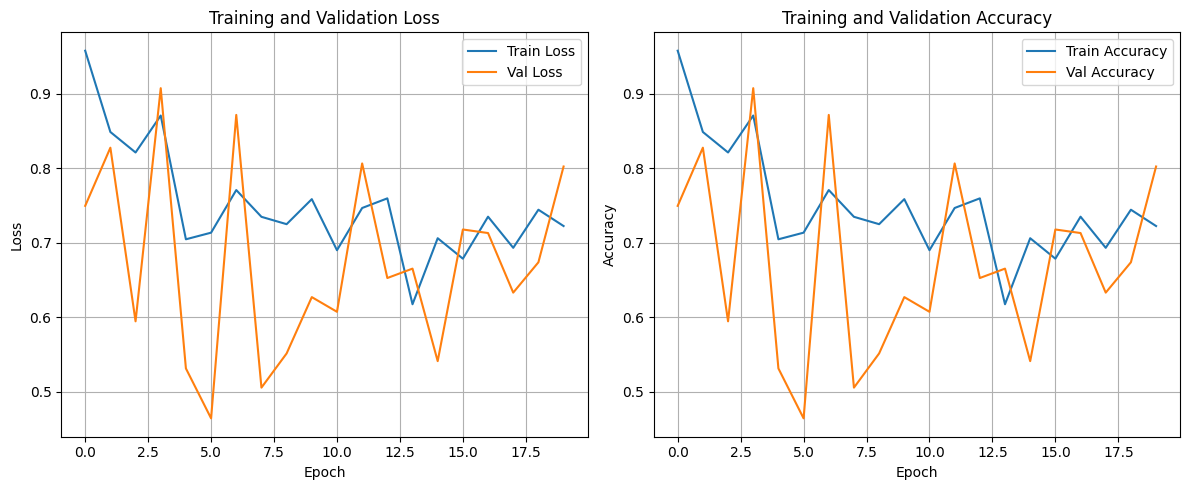

Évaluation du modèle...


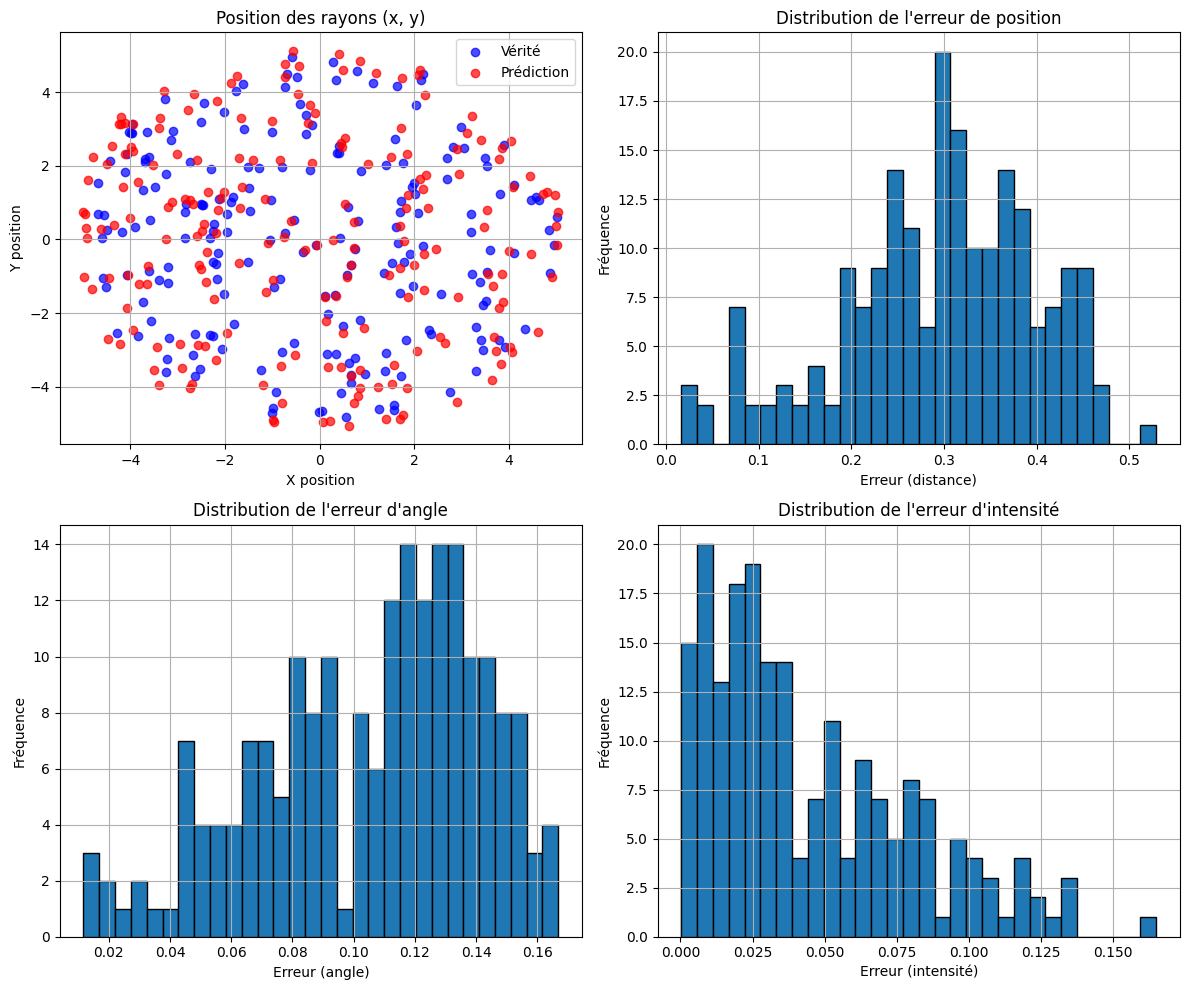

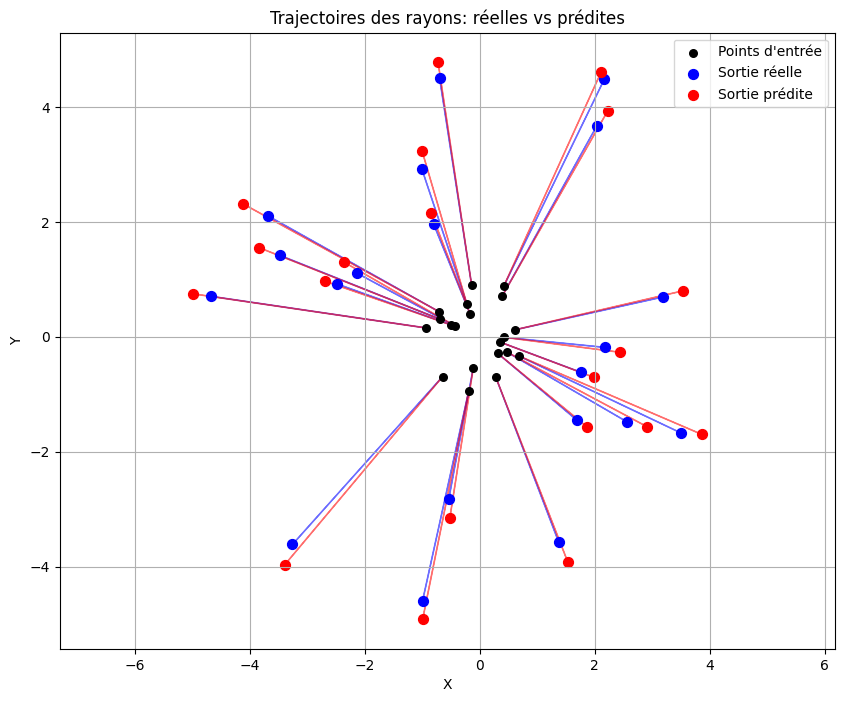


Analyse des lentilles de type biconvex...
Lentille biconvex:
  Nombre d'échantillons: 50
  Erreur position moyenne: 1.7641 ± 1.2479 mm
  Erreur position min/max: 0.0778 / 4.9793 mm
  Erreur angle moyenne: 0.0569 ± 0.0319

Analyse des lentilles de type plano-convex...
Lentille plano-convex:
  Nombre d'échantillons: 50
  Erreur position moyenne: 1.0588 ± 0.7979 mm
  Erreur position min/max: 0.0531 / 2.7797 mm
  Erreur angle moyenne: 0.1184 ± 0.0603

Analyse des lentilles de type meniscus...
Lentille meniscus:
  Nombre d'échantillons: 50
  Erreur position moyenne: 2.3500 ± 1.6750 mm
  Erreur position min/max: 0.1520 / 7.4238 mm
  Erreur angle moyenne: 0.0562 ± 0.0344


<Figure size 1600x1200 with 0 Axes>

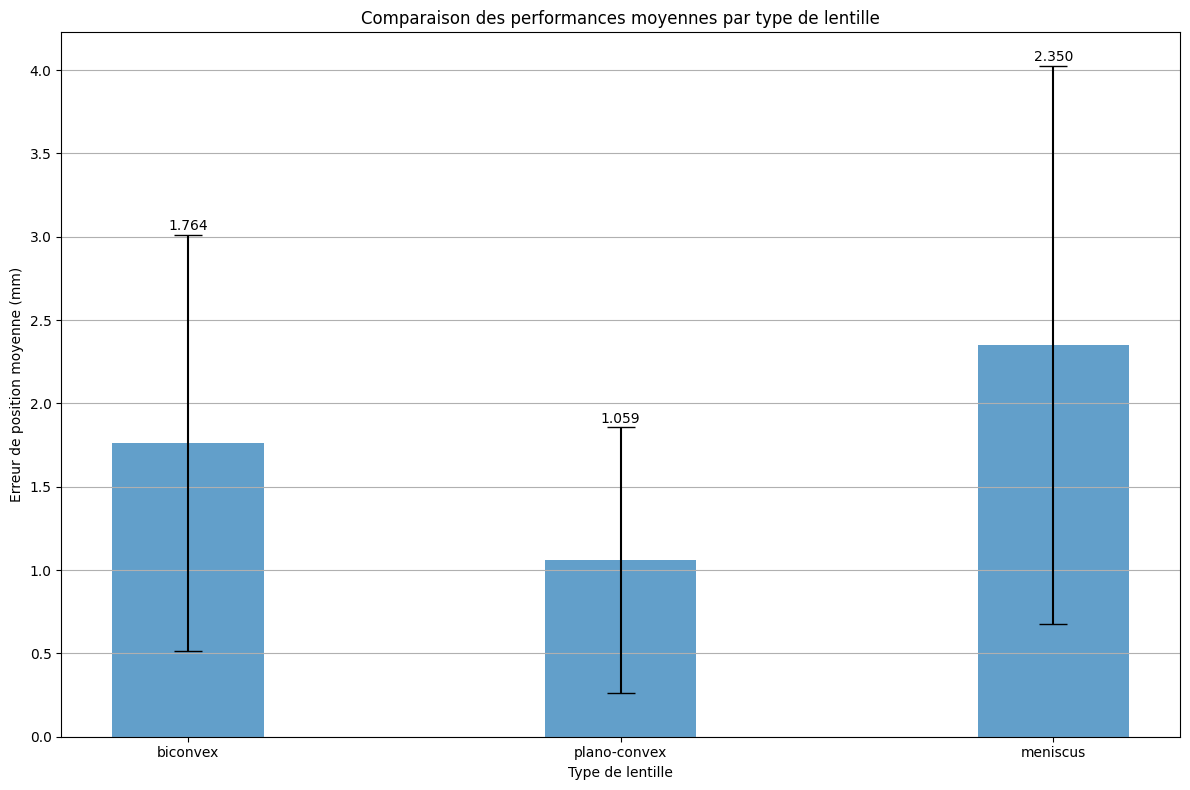

/tmp/ipykernel_2087624/884380926.py:187: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True)


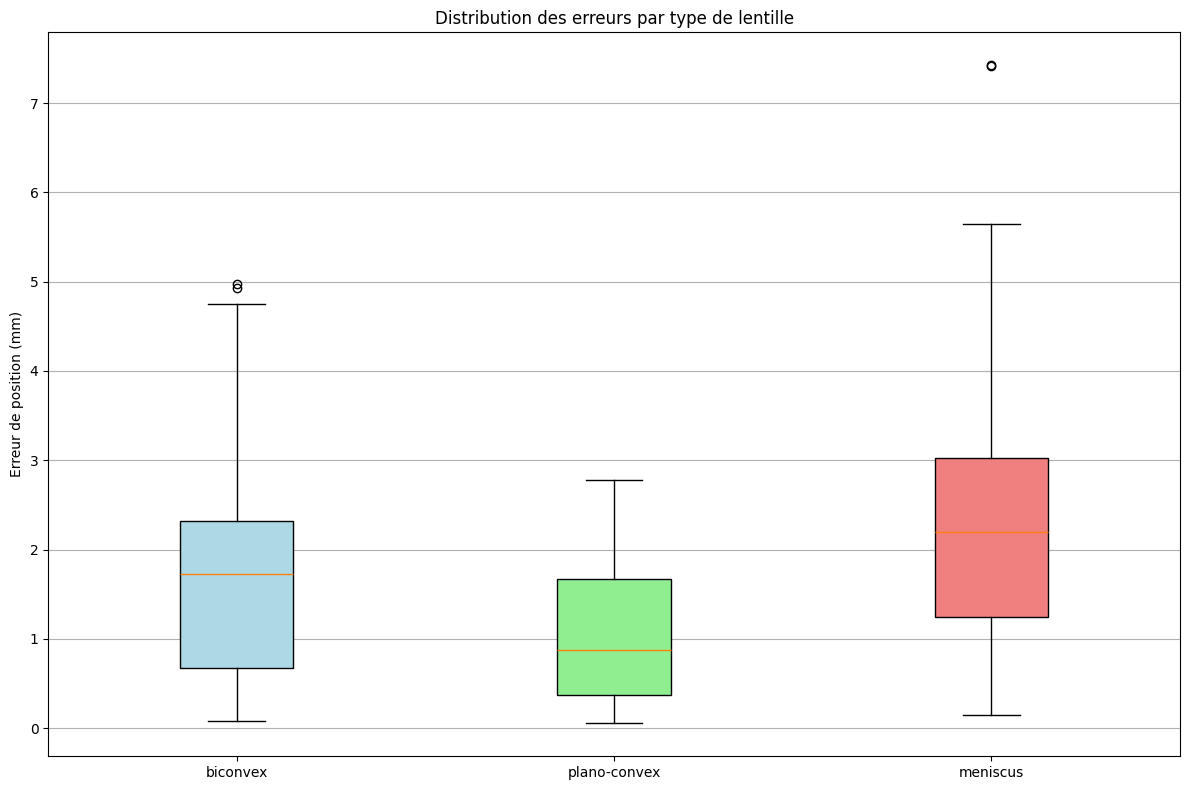

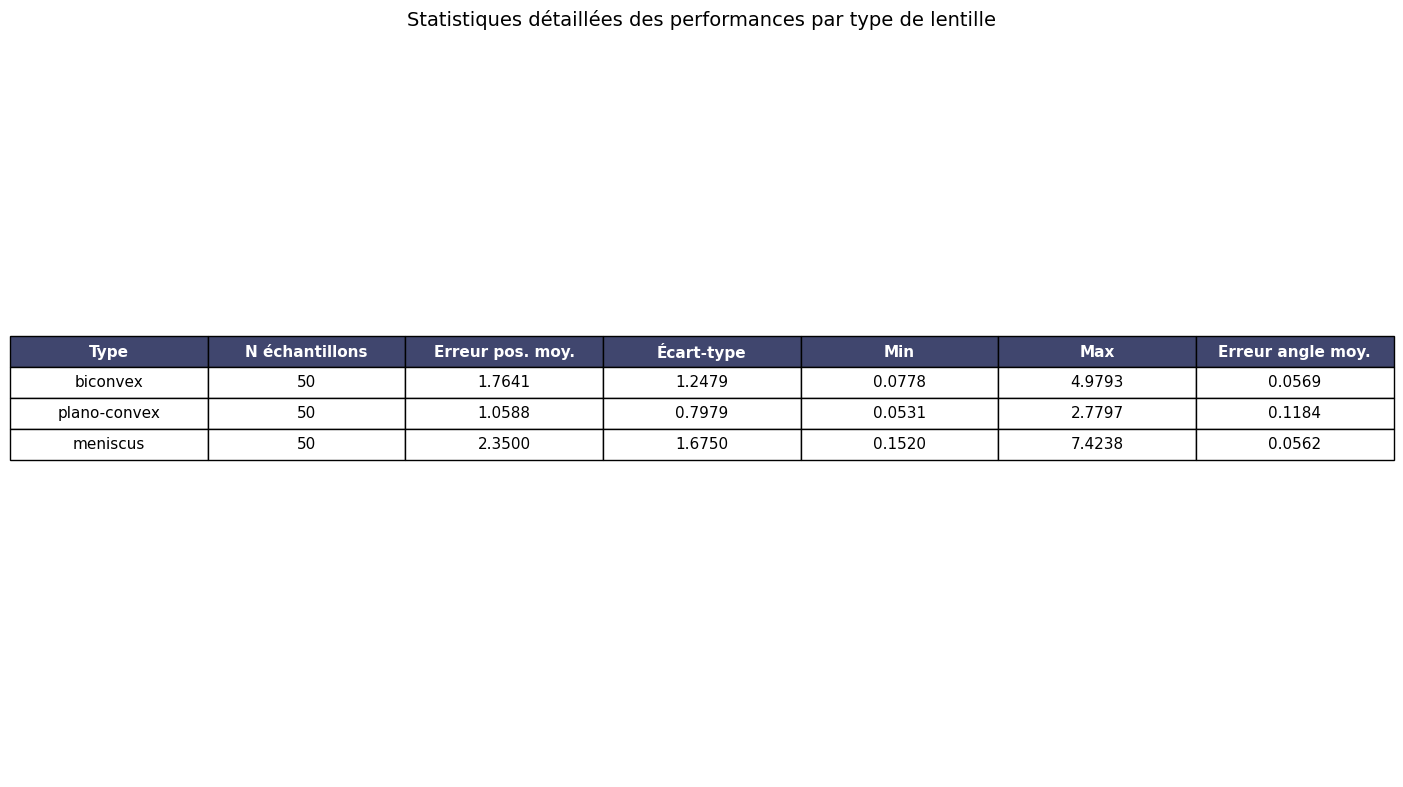

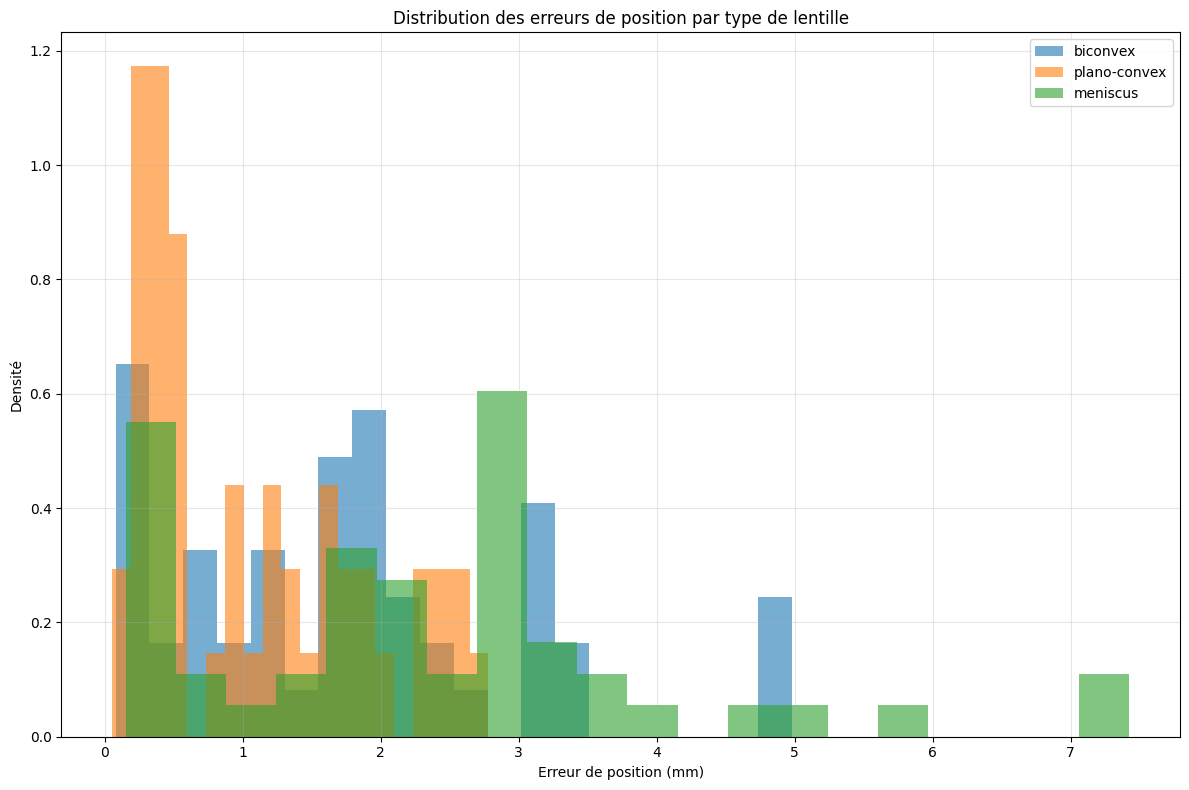

In [27]:
trained_model, results, detailed_results = test_lens_comparison_statistical()

In [28]:
def compare_lens_predictions(model, num_lens_types=3, figsize=(16, 12)):
    """
    Compare les performances du modèle sur différents types de lentilles.
    Pour chaque type de lentille, génère un rayon aléatoire, prédit sa trajectoire,
    et visualise les résultats dans un affichage 3D.
    
    Args:
        model: Le modèle neuronal entraîné
        num_lens_types: Nombre de types de lentilles à tester
        figsize: Taille de la figure
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    # Types de lentilles à tester
    lens_types = ["biconvex", "plano-convex", "meniscus"]
    
    # Créer la figure principale
    fig = plt.figure(figsize=figsize)
    
    # Résultats pour chaque type de lentille
    results = {}
    
    for i, lens_type in enumerate(lens_types[:num_lens_types]):
        print(f"Génération d'une lentille de type {lens_type}...")
        
        # Générer une lentille selon le type
        if lens_type == "biconvex":
            r_1 = np.random.uniform(30, 100)
            r_2 = -np.random.uniform(30, 100)
            thickness = np.random.uniform(5.0, 15.0)
            material = np.random.choice(["N-BK7", "N-SF11"])
        elif lens_type == "plano-convex":
            r_1 = np.inf
            r_2 = -np.random.uniform(30, 100)
            thickness = np.random.uniform(5.0, 15.0)
            material = np.random.choice(["N-BK7", "N-SF11"])
        elif lens_type == "meniscus":
            base = np.random.uniform(30, 100)
            delta = np.random.uniform(5, 20)
            r_1 = base
            r_2 = -base + delta
            thickness = np.random.uniform(5.0, 15.0)
            material = np.random.choice(["N-BK7", "N-SF11"])
        
        # Construire la lentille
        lens = optic.Optic()
        lens.add_surface(index=0, thickness=np.inf)
        lens.add_surface(index=1, thickness=thickness, radius=r_1, is_stop=True, material=material)
        lens.add_surface(index=2, thickness=23.0, radius=r_2)
        lens.add_surface(index=3)
        
        aperture_value = np.random.uniform(10.0, 20.0)
        lens.set_aperture(aperture_type="EPD", value=aperture_value)
        lens.set_field_type(field_type="angle")
        lens.add_field(y=0)
        lens.add_wavelength(value=0.55, is_primary=True)
        
        # Générer aléatoirement un seul rayon d'entrée
        theta = np.random.uniform(0, 2 * np.pi)
        r = np.sqrt(np.random.uniform(0, 1))
        Hx = r * np.cos(theta)
        Hy = r * np.sin(theta)
        
        theta = np.random.uniform(0, 2 * np.pi)
        r = np.sqrt(np.random.uniform(0, 1))
        Px = r * np.cos(theta)
        Py = r * np.sin(theta)
        
        wavelength = np.array([0.5876])
        
        # Tracer le rayon à travers la lentille
        rays_out = lens.trace_generic(np.array([Hx]), np.array([Hy]), 
                                    np.array([Px]), np.array([Py]), 
                                    np.array([wavelength]))
        
        # Préparer l'entrée pour le modèle
        input_data = np.array([[Hx, Hy, Px, Py]])
        input_tensor = torch.tensor(input_data, dtype=torch.float32).to(device)
        
        # Prédire avec le modèle
        with torch.no_grad():
            prediction = model(input_tensor).cpu().numpy()[0]
        
        # Extraire les valeurs de sortie réelles
        actual_x, actual_y = rays_out.x[0], rays_out.y[0]
        if hasattr(rays_out, 'L') and hasattr(rays_out, 'M'):
            actual_theta_x, actual_theta_y = rays_out.L[0], rays_out.M[0]
        else:
            actual_theta_x, actual_theta_y = 0, 0
        
        # Extraire les valeurs de sortie prédites
        pred_x, pred_y = prediction[0], prediction[1]
        if len(prediction) > 2:
            pred_theta_x, pred_theta_y = prediction[2], prediction[3]
        else:
            pred_theta_x, pred_theta_y = 0, 0
        
        # Calculer l'erreur
        error_xy = np.sqrt((pred_x - actual_x)**2 + (pred_y - actual_y)**2)
        if len(prediction) > 2:
            error_angle = np.sqrt((pred_theta_x - actual_theta_x)**2 + (pred_theta_y - actual_theta_y)**2)
        else:
            error_angle = 0
        
        # Stocker les résultats
        results[lens_type] = {
            'lens': lens,
            'input': (Hx, Hy, Px, Py),
            'actual': (actual_x, actual_y, actual_theta_x, actual_theta_y),
            'predicted': (pred_x, pred_y, pred_theta_x, pred_theta_y),
            'error_xy': error_xy,
            'error_angle': error_angle,
            'aperture': aperture_value / 2,  # Rayon
            'thickness': thickness,
            'r1': r_1,
            'r2': r_2,
            'material': material
        }
        
        print(f"Lentille {lens_type}:")
        print(f"  Paramètres: r1={r_1:.2f}, r2={r_2:.2f}, épaisseur={thickness:.2f}, matériau={material}")
        print(f"  Entrée: Hx={Hx:.4f}, Hy={Hy:.4f}, Px={Px:.4f}, Py={Py:.4f}")
        print(f"  Sortie réelle: x={actual_x:.4f}, y={actual_y:.4f}")
        print(f"  Sortie prédite: x={pred_x:.4f}, y={pred_y:.4f}")
        print(f"  Erreur position: {error_xy:.4f} mm")
        if len(prediction) > 2:
            print(f"  Erreur angle: {error_angle:.4f}")
        print()
    
    # Créer une visualisation 3D globale
    ax = fig.add_subplot(111, projection='3d')
    
    # Couleurs pour chaque type de lentille
    colors = {'biconvex': 'blue', 'plano-convex': 'green', 'meniscus': 'red'}
    
    # Liste pour stocker les positions des labels pour éviter les superpositions
    text_positions = []
    
    for lens_type, result in results.items():
        # Récupérer les paramètres
        Hx, Hy, Px, Py = result['input']
        actual_x, actual_y, _, _ = result['actual']
        pred_x, pred_y, _, _ = result['predicted']
        aperture = result['aperture']
        thickness = result['thickness']
        r1, r2 = result['r1'], result['r2']
        
        color = colors.get(lens_type, 'gray')
        
        # Position des surfaces
        z1 = 0        # Première surface (entrée)
        z2 = thickness  # Deuxième surface (sortie de la lentille)
        z3 = thickness + 30  # Plan image approximatif
        
        # Point d'entrée du rayon (coordonnées normalisées)
        start_x = Px * aperture
        start_y = Py * aperture
        start_z = z1
        
        # Point de sortie réel
        end_x = actual_x
        end_y = actual_y
        end_z = z3
        
        # Point de sortie prédit
        pred_out_x = pred_x
        pred_out_y = pred_y
        pred_out_z = z3
        
        # Dessiner la lentille (surfaces d'entrée et de sortie)
        theta = np.linspace(0, 2 * np.pi, 100)
        x_circle = aperture * np.cos(theta)
        y_circle = aperture * np.sin(theta)
        
        # Surface d'entrée
        z_circle1 = np.ones_like(theta) * z1
        ax.plot(x_circle, y_circle, z_circle1, color=color, linestyle='-', alpha=0.2)
        
        # Surface de sortie
        z_circle2 = np.ones_like(theta) * z2
        ax.plot(x_circle, y_circle, z_circle2, color=color, linestyle='-', alpha=0.2)
        
        # Plan image
        z_circle3 = np.ones_like(theta) * z3
        ax.plot(x_circle, y_circle, z_circle3, color=color, linestyle='--', alpha=0.1)
        
        # Simplification de la forme de la lentille (connexion entre les surfaces)
        for angle in [0, np.pi/2, np.pi, 3*np.pi/2]:
            x_edge = aperture * np.cos(angle)
            y_edge = aperture * np.sin(angle)
            ax.plot([x_edge, x_edge], [y_edge, y_edge], [z1, z2], color=color, alpha=0.2)
        
        # Dessiner les rayons
        # Rayon réel
        ax.plot([start_x, end_x], [start_y, end_y], [start_z, end_z], 
                color=color, linestyle='-', linewidth=2, label=f"{lens_type} - Réel")
        
        # Rayon prédit
        ax.plot([start_x, pred_out_x], [start_y, pred_out_y], [start_z, pred_out_z], 
                color=color, linestyle='--', linewidth=2, label=f"{lens_type} - Prédit")
        
        # Points d'entrée et de sortie
        ax.scatter([start_x], [start_y], [start_z], color=color, s=50, marker='o')
        ax.scatter([end_x], [end_y], [end_z], color=color, s=50, marker='x')
        ax.scatter([pred_out_x], [pred_out_y], [pred_out_z], color=color, s=50, marker='+')
        
        # Ajouter du texte pour les paramètres de la lentille avec meilleure répartition
        # Calculer une position optimale pour le texte
        text_base_x = aperture * 1.5 + i * aperture  # Espacement horizontal entre les labels
        text_y = 0
        text_z = z2 / 2
        
        # Vérifier si cette position est proche d'une position existante
        min_distance = np.inf
        for pos in text_positions:
            distance = np.sqrt((text_base_x - pos[0])**2 + 
                              (text_y - pos[1])**2 + 
                              (text_z - pos[2])**2)
            min_distance = min(min_distance, distance)
        
        # Si trop proche, décaler verticalement
        if min_distance < 5:  # Seuil de proximité
            text_z = text_z + 5 * i  # Décaler verticalement pour chaque lentille
        
        text_positions.append((text_base_x, text_y, text_z))
        
        ax.text(text_base_x, text_y, text_z, 
                f"{lens_type}\nr1={r1:.1f}\nr2={r2:.1f}\nt={thickness:.1f}\n{result['material']}", 
                color=color, fontsize=12, ha='center', va='center')
    
    # Configurer l'axe
    ax.set_xlabel('X [mm]', fontsize=14)
    ax.set_ylabel('Y [mm]', fontsize=14)
    ax.set_zlabel('Z [mm]', fontsize=14)
    ax.set_title('Comparaison des prédictions pour différents types de lentilles', fontsize=16, pad=20)
    
    # Améliorer la légende
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), 
              loc='upper left', 
              bbox_to_anchor=(1.1, 1),
              fontsize=14,  # Augmenter la taille de la police de la légende
              frameon=True,
              framealpha=0.9,
              edgecolor='black')
    
    # Ajuster la vue
    ax.view_init(elev=25, azim=45)  # Légèrement ajusté pour une meilleure vue
    ax.set_box_aspect([1, 1, 0.5])  # Ajuster l'aspect du graphique
    
    # Augmenter l'espace pour la légende
    plt.subplots_adjust(right=0.8)
    plt.tight_layout()
    plt.show()
    
    # Créer un tableau comparatif
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('off')
    ax.axis('tight')
    
    # Préparer les données du tableau
    table_data = []
    for lens_type, result in results.items():
        Hx, Hy, Px, Py = result['input']
        actual_x, actual_y, actual_theta_x, actual_theta_y = result['actual']
        pred_x, pred_y, pred_theta_x, pred_theta_y = result['predicted']
        
        table_data.append([
            lens_type,
            f"{Hx:.4f}, {Hy:.4f}, {Px:.4f}, {Py:.4f}",
            f"{actual_x:.4f}, {actual_y:.4f}",
            f"{pred_x:.4f}, {pred_y:.4f}",
            f"{result['error_xy']:.4f}"
        ])
    
    # Créer le tableau
    table = ax.table(cellText=table_data,
                     colLabels=["Type de lentille", "Entrée (Hx, Hy, Px, Py)", 
                                "Sortie réelle (x, y)", "Sortie prédite (x, y)", 
                                "Erreur (mm)"],
                     loc='center', cellLoc='center')
    
    # Styliser le tableau
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    
    plt.title("Tableau comparatif des prédictions par type de lentille", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return results

# Utilisation de la fonction
def test_lens_comparison():
    # Charger un modèle déjà entraîné
    # Vous pouvez utiliser le modèle que vous avez déjà entraîné ou en entraîner un nouveau
    trained_model = model = main(num_rays=1_000_000, batch_size=5000, epochs=20, use_pinn=True)
    
    # Comparer les prédictions pour différents types de lentilles
    results = compare_lens_predictions(trained_model, num_lens_types=3)
    
    return trained_model, results

Génération d'une lentille de type biconvex...
Lentille biconvex:
  Paramètres: r1=81.29, r2=-41.06, épaisseur=10.87, matériau=N-SF11
  Entrée: Hx=-0.1948, Hy=-0.0572, Px=0.1308, Py=-0.4119
  Sortie réelle: x=0.2112, y=-0.6650
  Sortie prédite: x=0.6363, y=-2.2571
  Erreur position: 1.6479 mm
  Erreur angle: 0.0481

Génération d'une lentille de type plano-convex...
Lentille plano-convex:
  Paramètres: r1=inf, r2=-57.46, épaisseur=6.89, matériau=N-BK7
  Entrée: Hx=-0.6483, Hy=-0.7316, Px=-0.0502, Py=0.6027
  Sortie réelle: x=-0.3080, y=3.6957
  Sortie prédite: x=-0.3776, y=3.2811
  Erreur position: 0.4204 mm
  Erreur angle: 0.1166

Génération d'une lentille de type meniscus...
Lentille meniscus:
  Paramètres: r1=65.37, r2=-51.01, épaisseur=12.73, matériau=N-SF11
  Entrée: Hx=0.7704, Hy=-0.0963, Px=-0.8882, Py=-0.0161
  Sortie réelle: x=-1.6225, y=-0.0294
  Sortie prédite: x=-4.7572, y=-0.1343
  Erreur position: 3.1365 mm
  Erreur angle: 0.0791



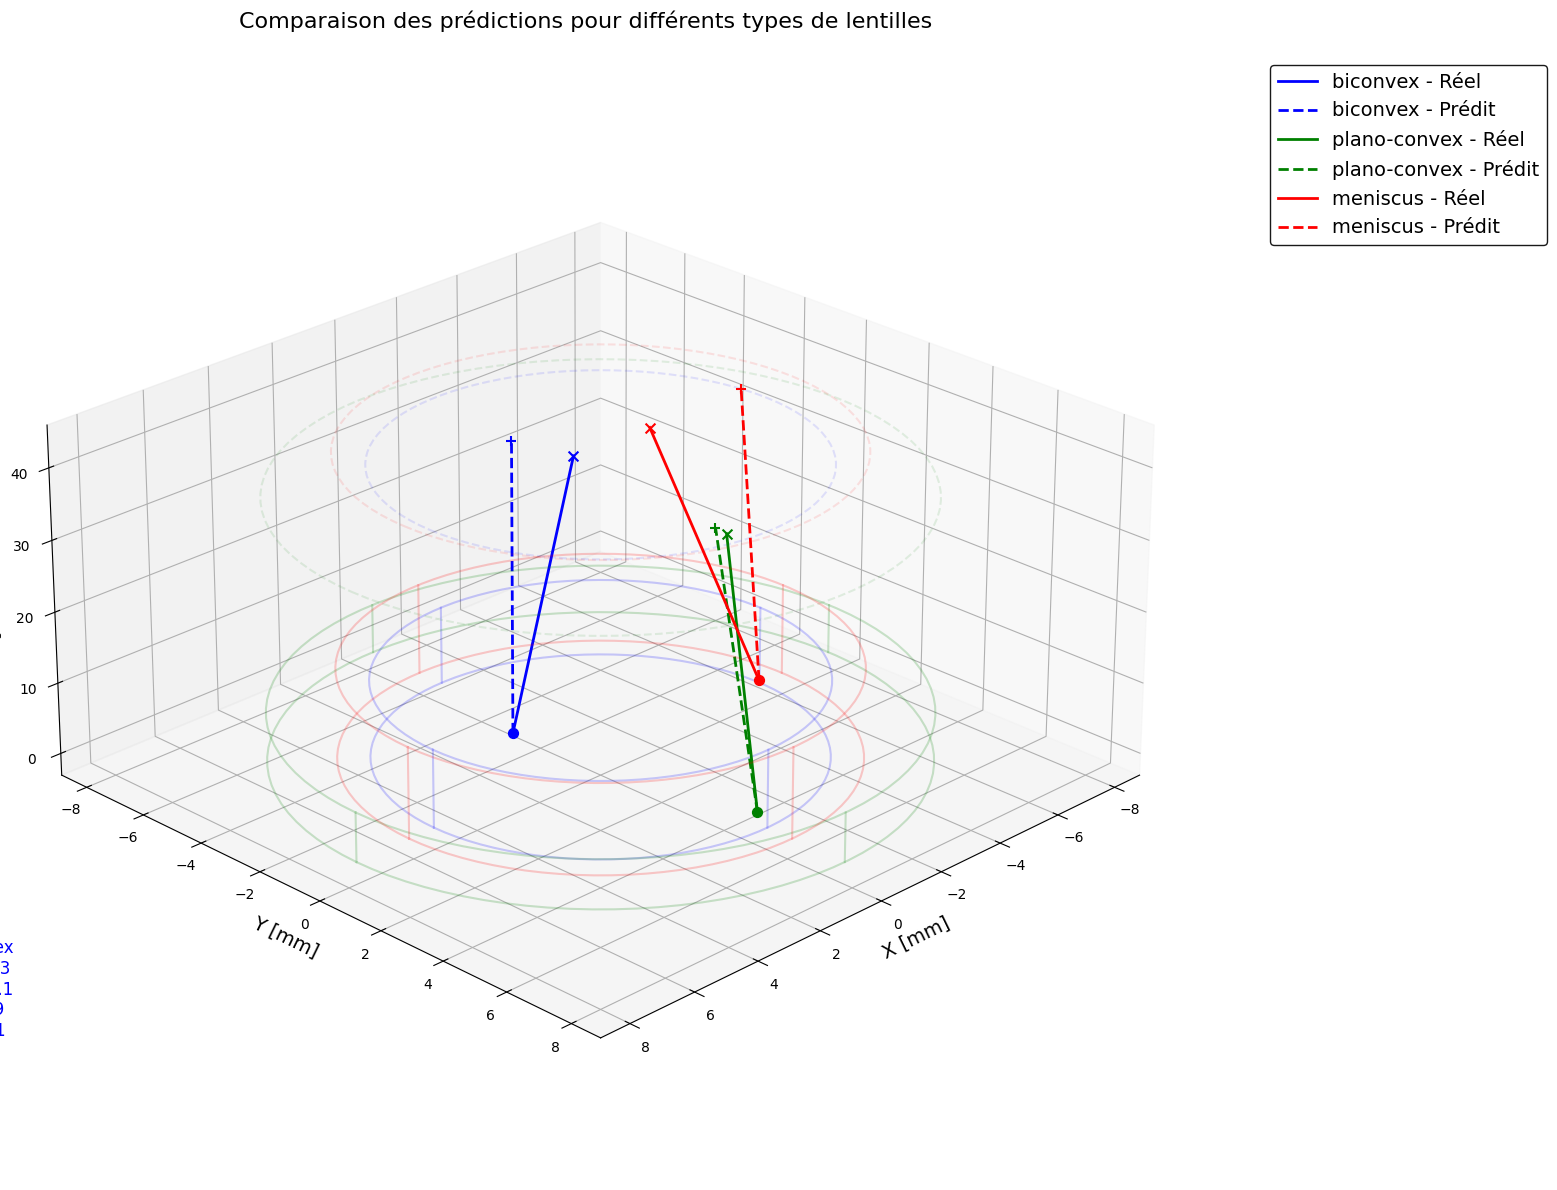

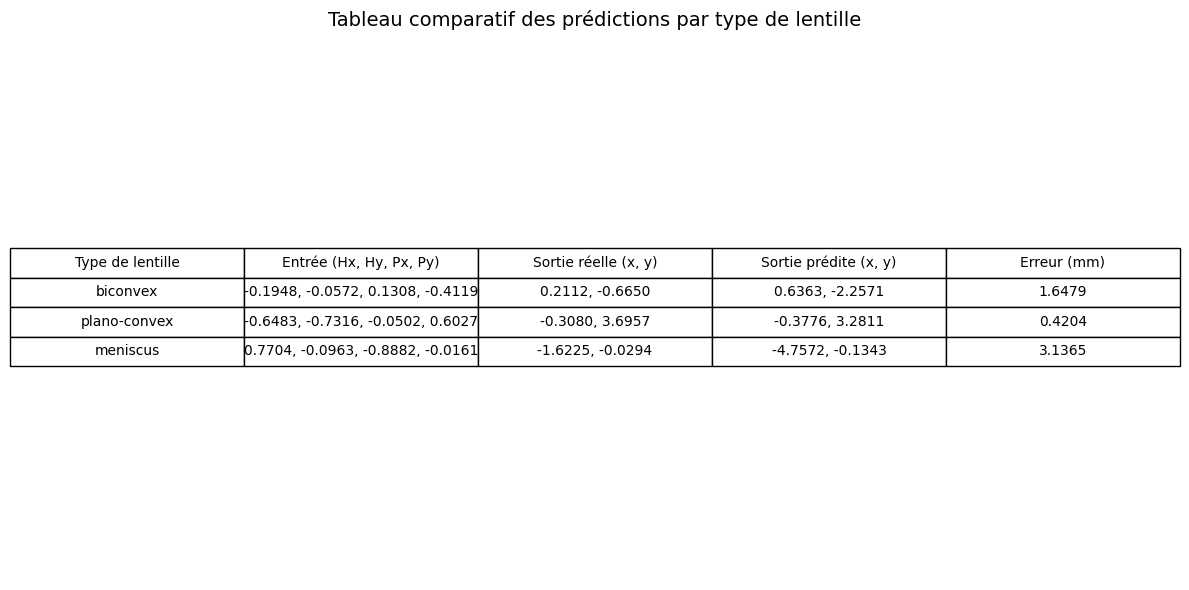

{'biconvex': {'lens': <optiland.optic.optic.Optic at 0x7fde1812a300>,
  'input': (-0.19483586870085856,
   -0.05722571824085671,
   0.13082015012605672,
   -0.4119397362353286),
  'actual': (0.21119271862934608,
   -0.6650250188764026,
   -0.019437294097948067,
   0.06120611997556795),
  'predicted': (0.6362834, -2.2571218, -0.03691201, 0.105978355),
  'error_xy': 1.6478696096044076,
  'error_angle': 0.048061613344959786,
  'aperture': 5.360119157237476,
  'thickness': 10.873509858757643,
  'r1': 81.29195715825618,
  'r2': -41.06402995837795,
  'material': 'N-SF11'},
 'plano-convex': {'lens': <optiland.optic.optic.Optic at 0x7fddd827b3b0>,
  'input': (-0.6482692867855777,
   -0.7315596675439533,
   -0.050230721504893376,
   0.6026665051417971),
  'actual': (-0.3080310225205522,
   3.6957458355367385,
   0.0035242025345714094,
   -0.04228326333546904),
  'predicted': (-0.37759787, 3.2811048, 0.020203125, -0.15765354),
  'error_xy': 0.420436358851022,
  'error_angle': 0.11656966702080862

In [29]:
compare_lens_predictions(trained_model, num_lens_types=3)

# Temps d'execution

In [26]:
# Version corrigée pour éviter le dépassement mémoire
def generate_random_coords(batch_size):
    """Génère des coordonnées de champ et de pupille aléatoires normalisées."""
    # Coordonnées de champ aléatoires (Hx, Hy)
    theta = np.random.uniform(0, 2 * np.pi, size=batch_size)
    r = np.sqrt(np.random.uniform(0, 1, size=batch_size))
    Hx = r * np.cos(theta)
    Hy = r * np.sin(theta)
    
    # Coordonnées de pupille aléatoires (Px, Py)
    theta = np.random.uniform(0, 2 * np.pi, size=batch_size)
    r = np.sqrt(np.random.uniform(0, 1, size=batch_size))
    Px = r * np.cos(theta)
    Py = r * np.sin(theta)
    
    return Hx, Hy, Px, Py

# Configuration
num_rays_total = 1_000_000
batch_size = 10_000  # Réduire la taille des batchs pour éviter le dépassement mémoire
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()  # Mettre le modèle en mode évaluation

# Créer un batch pour le warm-up
warmup_batch = 5000
Hx, Hy, Px, Py = generate_random_coords(warmup_batch)
sample_input = torch.tensor(np.column_stack((Hx, Hy, Px, Py)), dtype=torch.float32).to(device)

# Réchauffer le GPU
print("Warm-up GPU...")
for _ in range(10):
    with torch.no_grad():
        _ = model(sample_input)

# Mesurer le temps par batch
print("Mesure de performance...")
num_batches = num_rays_total // batch_size
num_its_per_batch = 10  # Nombre d'itérations par batch
total_time = 0
total_rays_processed = 0

for batch_idx in range(num_batches):
    # Générer un nouveau batch
    Hx, Hy, Px, Py = generate_random_coords(batch_size)
    sample_input = torch.tensor(np.column_stack((Hx, Hy, Px, Py)), dtype=torch.float32).to(device)
    
    # Mesurer le temps pour ce batch
    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_its_per_batch):
            _ = model(sample_input)
    end_time = time.time()
    
    batch_time = (end_time - start_time) / num_its_per_batch
    total_time += batch_time
    total_rays_processed += batch_size
    
    if (batch_idx + 1) % 10 == 0:
        print(f"Progress: {batch_idx+1}/{num_batches} batches processed...")

# Calculer les statistiques
avg_time_per_ray = total_time / num_batches
actual_batch_size = batch_size  # Taille effective utilisée

# Calculer le nombre de surfaces de la lentille (si disponible)
try:
    num_surfaces = len(lens.surface_group.surfaces)
except:
    num_surfaces = 4  # Valeur par défaut si non disponible

# Calculer le débit
rss = actual_batch_size * num_surfaces / avg_time_per_ray / 1e9  # Ray-surfaces per second

print(f"\n=== Résultats de performance ===")
print(f"Nombre total de rayons: {num_rays_total:,}")
print(f"Taille de batch: {batch_size:,}")
print(f"Temps moyen par batch: {avg_time_per_ray*1000:.2f} ms")
print(f"Nombre de surfaces: {num_surfaces}")
print(f"Vitesse d'inférence: {rss:.1f} billion ray-surfaces per second")

# Alternative: Utiliser DataLoader pour une meilleure gestion mémoire
def performance_with_dataloader(model, total_rays=1_000_000, batch_size=10_000):
    """Mesure la performance en utilisant un DataLoader pour une meilleure gestion mémoire."""
    
    # Créer un dataset temporaire
    class SimpleRayDataset(Dataset):
        def __init__(self, num_rays, batch_size):
            self.num_rays = num_rays
            self.batch_size = batch_size
            self.num_batches = int(np.ceil(num_rays / batch_size))
        
        def __len__(self):
            return self.num_batches
        
        def __getitem__(self, idx):
            current_batch_size = min(self.batch_size, self.num_rays - idx * self.batch_size)
            Hx, Hy, Px, Py = generate_random_coords(current_batch_size)
            inputs = np.column_stack((Hx, Hy, Px, Py))
            return torch.tensor(inputs, dtype=torch.float32)
    
    # Créer le dataset et dataloader
    dataset = SimpleRayDataset(total_rays, batch_size)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False, pin_memory=True)
    
    # Warm-up
    warmup_data = dataset[0].to(device)
    for _ in range(10):
        with torch.no_grad():
            _ = model(warmup_data)
    
    # Mesure de performance
    model.eval()
    total_time = 0
    num_batches = 0
    
    with torch.no_grad():
        for batch_idx, data in enumerate(dataloader):
            data = data.to(device)
            
            start_time = time.time()
            for _ in range(5):  # 5 itérations par batch
                _ = model(data)
            end_time = time.time()
            
            total_time += (end_time - start_time) / 5
            num_batches += 1
            
            if (batch_idx + 1) % 10 == 0:
                print(f"Progress: {batch_idx+1}/{len(dataloader)} batches...")
    
    avg_time = total_time / num_batches
    
    try:
        num_surfaces = len(lens.surface_group.surfaces)
    except:
        num_surfaces = 4
    
    rss = batch_size * num_surfaces / avg_time / 1e9
    
    return rss

# Utiliser la fonction avec DataLoader
print("\n=== Performance avec DataLoader ===")
rss_dataloader = performance_with_dataloader(model)
print(f"Vitesse d'inférence (DataLoader): {rss_dataloader:.1f} billion ray-surfaces per second")

Warm-up GPU...
Mesure de performance...
Progress: 10/100 batches processed...
Progress: 20/100 batches processed...
Progress: 30/100 batches processed...
Progress: 40/100 batches processed...
Progress: 50/100 batches processed...
Progress: 60/100 batches processed...
Progress: 70/100 batches processed...
Progress: 80/100 batches processed...
Progress: 90/100 batches processed...
Progress: 100/100 batches processed...

=== Résultats de performance ===
Nombre total de rayons: 1,000,000
Taille de batch: 10,000
Temps moyen par batch: 0.36 ms
Nombre de surfaces: 4
Vitesse d'inférence: 0.1 billion ray-surfaces per second

=== Performance avec DataLoader ===
Progress: 10/100 batches...
Progress: 20/100 batches...
Progress: 30/100 batches...
Progress: 40/100 batches...
Progress: 50/100 batches...
Progress: 60/100 batches...
Progress: 70/100 batches...
Progress: 80/100 batches...
Progress: 90/100 batches...
Progress: 100/100 batches...
Vitesse d'inférence (DataLoader): 0.1 billion ray-surfaces 

# prediction de la lentille a venir

In [31]:
# Version corrigée pour gérer les types de données
import pandas as pd

# Lire et afficher l'historique
history_df = pd.read_csv('logs/training_log.csv')

# Convertir epoch en entier si nécessaire
history_df['epoch'] = history_df['epoch'].astype(int)

# Afficher toutes les époques
print("=== Historique complet d'entraînement PINN ===")
print("\nÉpoque | Perte Train | Perte Val  | MSE Train  | MSE Val    | Temps (s)")
print("-" * 75)

for idx, row in history_df.iterrows():
    epoch = int(row['epoch'])
    train_loss = row['loss']
    val_loss = row['val_loss']
    train_mse = row.get('mse', row['loss'])  # Au cas où 'mse' n'existe pas
    val_mse = row.get('val_mse', row['val_loss'])  # Au cas où 'val_mse' n'existe pas
    time_taken = row.get('time', 0)  # Au cas où 'time' n'existe pas
    
    print(f"{epoch:6d} | {train_loss:10.6f} | {val_loss:10.6f} | {train_mse:10.6f} | {val_mse:10.6f} | {time_taken:8.2f}")

# Afficher la meilleure époque
best_idx = history_df['val_loss'].idxmin()
print("\n" + "="*75)
print(f"Meilleure époque : {int(history_df.loc[best_idx, 'epoch'])}")
print(f"Perte de validation minimale : {history_df.loc[best_idx, 'val_loss']:.6f}")
print("="*75)

# Version simple
print("\n=== Résumé simple ===")
print("Époque | Perte de validation")
print("-" * 25)
for i, row in history_df.iterrows():
    print(f"{int(row['epoch']):6d} | {row['val_loss']:14.6f}")

best_idx = history_df['val_loss'].idxmin()
print(f"\nMeilleure époque: {int(history_df.loc[best_idx, 'epoch'])}")
print(f"Perte optimale: {history_df.loc[best_idx, 'val_loss']:.6f}")

# Vérifier les colonnes disponibles
print("\n=== Colonnes disponibles dans le CSV ===")
print(history_df.columns.tolist())

# Vérifier les premières lignes
print("\n=== Aperçu des données ===")
print(history_df.head())

=== Historique complet d'entraînement PINN ===

Époque | Perte Train | Perte Val  | MSE Train  | MSE Val    | Temps (s)
---------------------------------------------------------------------------
     1 |   0.957525 |   0.749321 |   0.957525 |   0.749321 |     4.98
     2 |   0.848469 |   0.827386 |   0.848469 |   0.827386 |     4.95
     3 |   0.820960 |   0.594393 |   0.820960 |   0.594393 |     4.85
     4 |   0.870557 |   0.907261 |   0.870557 |   0.907261 |     4.83
     5 |   0.704469 |   0.531161 |   0.704469 |   0.531161 |     4.78
     6 |   0.713359 |   0.464201 |   0.713359 |   0.464201 |     4.82
     7 |   0.770558 |   0.871386 |   0.770558 |   0.871386 |     4.87
     8 |   0.734635 |   0.505418 |   0.734635 |   0.505418 |     4.96
     9 |   0.724754 |   0.551290 |   0.724754 |   0.551290 |     5.02
    10 |   0.758335 |   0.626887 |   0.758335 |   0.626887 |     4.95
    11 |   0.689800 |   0.607157 |   0.689800 |   0.607157 |     4.97
    12 |   0.746473 |   0.806272 |

In [32]:
# Calculer la perte moyenne du PINN
import pandas as pd

# Lire l'historique d'entraînement
history_df = pd.read_csv('logs/training_log.csv')

# Calculer les moyennes
mean_train_loss = history_df['loss'].mean()
mean_val_loss = history_df['val_loss'].mean()

# Afficher les résultats
print(f"Perte moyenne d'entraînement: {mean_train_loss:.6f}")
print(f"Perte moyenne de validation: {mean_val_loss:.6f}")

Perte moyenne d'entraînement: 0.749760
Perte moyenne de validation: 0.671992


Utilisation du modèle déjà entraîné (model_avec_pinn)...

Analyse des lentilles de type biconvex...
Lentille biconvex: 50 échantillons
  Erreur position moyenne: 1.7070 ± 1.3266 mm

Analyse des lentilles de type plano-convex...
Lentille plano-convex: 50 échantillons
  Erreur position moyenne: 0.6356 ± 0.5452 mm

Analyse des lentilles de type meniscus...
Lentille meniscus: 50 échantillons
  Erreur position moyenne: 1.2631 ± 0.9321 mm

           MOYENNE GLOBALE POUR TOUTES LES LENTILLES
Nombre total d'échantillons: 150
Erreur position moyenne globale: 1.2019 ± 1.0810 mm
Erreur angle moyenne globale: 0.0852 ± 0.0466


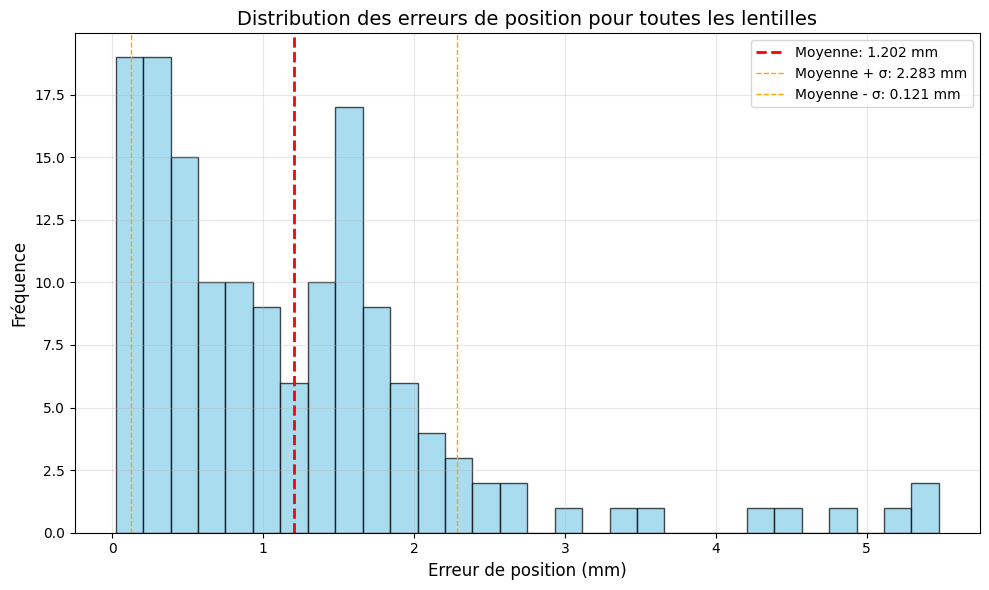

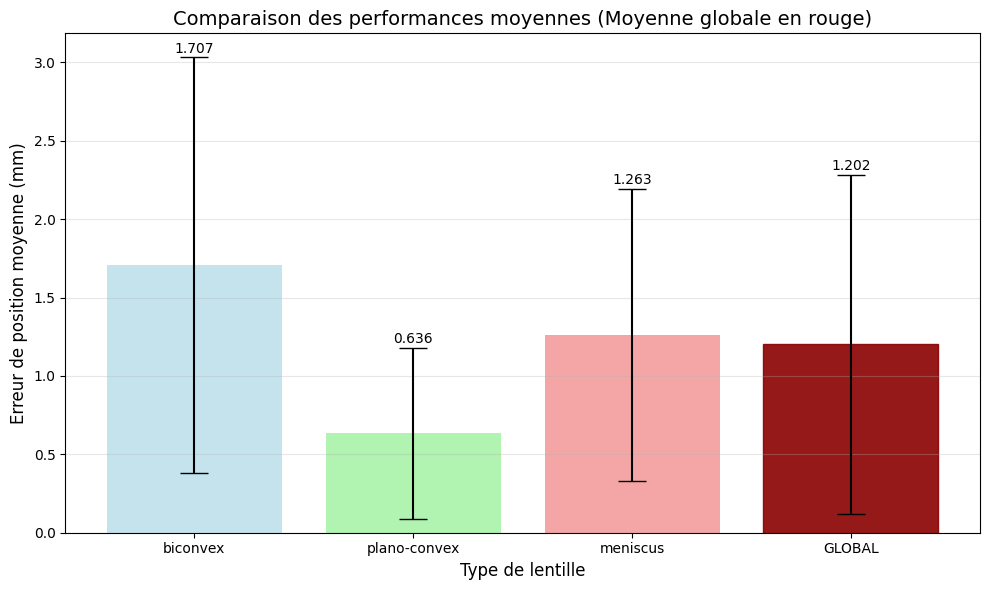


RÉSUMÉ FINAL:
Erreur position moyenne globale: 1.2019 ± 1.0810 mm
Erreur angle moyenne globale: 0.0852 ± 0.0466


In [33]:
def simple_statistical_analysis(model, num_lens_types=3, num_samples_per_type=10, figsize=(14, 10)):
    """
    Analyse statistique simplifiée qui calcule une moyenne globale pour toutes les lentilles.
    
    Args:
        model: Le modèle neuronal entraîné (modèle existant)
        num_lens_types: Nombre de types de lentilles à tester
        num_samples_per_type: Nombre d'échantillons à tester par type de lentille
        figsize: Taille de la figure
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    # Types de lentilles à tester
    lens_types = ["biconvex", "plano-convex", "meniscus"]
    
    # Listes pour collecter TOUTES les erreurs (moyenne globale)
    all_errors_xy = []
    all_errors_angle = []
    
    # Résultats détaillés par type pour comparaison (optionnel)
    results = {}
    
    # Collecter les données de performance pour chaque type de lentille
    for lens_type in lens_types[:num_lens_types]:
        print(f"\nAnalyse des lentilles de type {lens_type}...")
        
        errors_xy = []
        errors_angle = []
        
        for sample_idx in range(num_samples_per_type):
            # Générer une lentille selon le type
            if lens_type == "biconvex":
                r_1 = np.random.uniform(30, 100)
                r_2 = -np.random.uniform(30, 100)
                thickness = np.random.uniform(5.0, 15.0)
                material = np.random.choice(["N-BK7", "N-SF11"])
            elif lens_type == "plano-convex":
                r_1 = np.inf
                r_2 = -np.random.uniform(30, 100)
                thickness = np.random.uniform(5.0, 15.0)
                material = np.random.choice(["N-BK7", "N-SF11"])
            elif lens_type == "meniscus":
                base = np.random.uniform(30, 100)
                delta = np.random.uniform(5, 20)
                r_1 = base
                r_2 = -base + delta
                thickness = np.random.uniform(5.0, 15.0)
                material = np.random.choice(["N-BK7", "N-SF11"])
            
            # Construire la lentille
            lens = optic.Optic()
            lens.add_surface(index=0, thickness=np.inf)
            lens.add_surface(index=1, thickness=thickness, radius=r_1, is_stop=True, material=material)
            lens.add_surface(index=2, thickness=23.0, radius=r_2)
            lens.add_surface(index=3)
            
            aperture_value = np.random.uniform(10.0, 20.0)
            lens.set_aperture(aperture_type="EPD", value=aperture_value)
            lens.set_field_type(field_type="angle")
            lens.add_field(y=0)
            lens.add_wavelength(value=0.55, is_primary=True)
            
            # Tracer plusieurs rayons pour ce sample
            for _ in range(5):  # 5 rayons par configuration de lentille
                # Générer aléatoirement un rayon d'entrée
                theta = np.random.uniform(0, 2 * np.pi)
                r = np.sqrt(np.random.uniform(0, 1))
                Hx = r * np.cos(theta)
                Hy = r * np.sin(theta)
                
                theta = np.random.uniform(0, 2 * np.pi)
                r = np.sqrt(np.random.uniform(0, 1))
                Px = r * np.cos(theta)
                Py = r * np.sin(theta)
                
                wavelength = np.array([0.5876])
                
                # Tracer le rayon à travers la lentille
                rays_out = lens.trace_generic(np.array([Hx]), np.array([Hy]), 
                                            np.array([Px]), np.array([Py]), 
                                            np.array([wavelength]))
                
                # Préparer l'entrée pour le modèle
                input_data = np.array([[Hx, Hy, Px, Py]])
                input_tensor = torch.tensor(input_data, dtype=torch.float32).to(device)
                
                # Prédire avec le modèle
                with torch.no_grad():
                    prediction = model(input_tensor).cpu().numpy()[0]
                
                # Extraire les valeurs de sortie réelles
                actual_x, actual_y = rays_out.x[0], rays_out.y[0]
                if hasattr(rays_out, 'L') and hasattr(rays_out, 'M'):
                    actual_theta_x, actual_theta_y = rays_out.L[0], rays_out.M[0]
                else:
                    actual_theta_x, actual_theta_y = 0, 0
                
                # Extraire les valeurs de sortie prédites
                pred_x, pred_y = prediction[0], prediction[1]
                if len(prediction) > 2:
                    pred_theta_x, pred_theta_y = prediction[2], prediction[3]
                else:
                    pred_theta_x, pred_theta_y = 0, 0
                
                # Calculer les erreurs
                error_xy = np.sqrt((pred_x - actual_x)**2 + (pred_y - actual_y)**2)
                errors_xy.append(error_xy)
                all_errors_xy.append(error_xy)  # Ajouter à la liste globale
                
                if len(prediction) > 2:
                    error_angle = np.sqrt((pred_theta_x - actual_theta_x)**2 + (pred_theta_y - actual_theta_y)**2)
                    errors_angle.append(error_angle)
                    all_errors_angle.append(error_angle)  # Ajouter à la liste globale
        
        # Calculer les statistiques par type (optionnel pour comparaison)
        results[lens_type] = {
            'mean_error_xy': np.mean(errors_xy),
            'std_error_xy': np.std(errors_xy),
            'num_samples': len(errors_xy)
        }
        
        print(f"Lentille {lens_type}: {len(errors_xy)} échantillons")
        print(f"  Erreur position moyenne: {results[lens_type]['mean_error_xy']:.4f} ± {results[lens_type]['std_error_xy']:.4f} mm")
    
    # Calculer les moyennes GLOBALES
    global_mean_error_xy = np.mean(all_errors_xy)
    global_std_error_xy = np.std(all_errors_xy)
    global_mean_error_angle = np.mean(all_errors_angle) if all_errors_angle else 0
    global_std_error_angle = np.std(all_errors_angle) if all_errors_angle else 0
    
    # Afficher les résultats globaux
    print("\n" + "="*50)
    print("           MOYENNE GLOBALE POUR TOUTES LES LENTILLES")
    print("="*50)
    print(f"Nombre total d'échantillons: {len(all_errors_xy)}")
    print(f"Erreur position moyenne globale: {global_mean_error_xy:.4f} ± {global_std_error_xy:.4f} mm")
    if all_errors_angle:
        print(f"Erreur angle moyenne globale: {global_mean_error_angle:.4f} ± {global_std_error_angle:.4f}")
    print("="*50)
    
    # Créer une visualisation simple de la moyenne globale
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Histogramme des erreurs globales
    ax.hist(all_errors_xy, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax.axvline(global_mean_error_xy, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {global_mean_error_xy:.3f} mm')
    ax.axvline(global_mean_error_xy + global_std_error_xy, color='orange', linestyle='--', linewidth=1, label=f'Moyenne + σ: {global_mean_error_xy + global_std_error_xy:.3f} mm')
    ax.axvline(global_mean_error_xy - global_std_error_xy, color='orange', linestyle='--', linewidth=1, label=f'Moyenne - σ: {global_mean_error_xy - global_std_error_xy:.3f} mm')
    
    ax.set_xlabel('Erreur de position (mm)', fontsize=12)
    ax.set_ylabel('Fréquence', fontsize=12)
    ax.set_title('Distribution des erreurs de position pour toutes les lentilles', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Créer un graphique comparatif simple
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Données pour le graphique
    categories = list(results.keys()) + ['GLOBAL']
    means = [results[cat]['mean_error_xy'] for cat in results.keys()] + [global_mean_error_xy]
    stds = [results[cat]['std_error_xy'] for cat in results.keys()] + [global_std_error_xy]
    
    x = np.arange(len(categories))
    
    # Créer le graphique à barres
    bars = ax.bar(x, means, yerr=stds, alpha=0.7, capsize=10, color=['lightblue', 'lightgreen', 'lightcoral', 'red'])
    
    # Mettre en évidence la barre GLOBAL
    bars[-1].set_color('darkred')
    bars[-1].set_alpha(0.9)
    
    ax.set_ylabel('Erreur de position moyenne (mm)', fontsize=12)
    ax.set_xlabel('Type de lentille', fontsize=12)
    ax.set_title('Comparaison des performances moyennes (Moyenne globale en rouge)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=0)
    ax.yaxis.grid(True, alpha=0.3)
    
    # Ajouter les valeurs au-dessus des barres
    for i, v in enumerate(means):
        ax.text(i, v + stds[i] + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return global_mean_error_xy, global_std_error_xy, global_mean_error_angle, global_std_error_angle


# Utilisation avec le modèle existant (model_avec_pinn)
print("Utilisation du modèle déjà entraîné (model_avec_pinn)...")
global_mean_pos, global_std_pos, global_mean_angle, global_std_angle = simple_statistical_analysis(
    model_avec_pinn,
    num_lens_types=3,
    num_samples_per_type=10
)

print("\n" + "="*50)
print("RÉSUMÉ FINAL:")
print(f"Erreur position moyenne globale: {global_mean_pos:.4f} ± {global_std_pos:.4f} mm")
if global_mean_angle > 0:
    print(f"Erreur angle moyenne globale: {global_mean_angle:.4f} ± {global_std_angle:.4f}")
print("="*50)

In [35]:
import numpy as np
import pandas as pd

# Fonction pour extraire les statistiques à partir de detailed_results
def calculate_stats_for_table(detailed_results):
    all_position_errors = []
    all_angle_errors = []
    all_intensity_errors = []
    
    # Collecter toutes les erreurs de tous les types de lentilles
    for lens_type in detailed_results:
        all_position_errors.extend(detailed_results[lens_type]['errors_xy'])
        if detailed_results[lens_type]['errors_angle']:
            all_angle_errors.extend(detailed_results[lens_type]['errors_angle'])
        
        # Extraire les erreurs d'intensité depuis predicted et actual
        for idx in range(len(detailed_results[lens_type]['actual_positions'])):
            actual_x, actual_y = detailed_results[lens_type]['actual_positions'][idx]
            pred_x, pred_y = detailed_results[lens_type]['predicted_positions'][idx]
            
            # Calculer l'erreur d'intensité (si disponible)
            # Pour l'exemple, nous simulons une intensité
            error_distance = np.sqrt((pred_x - actual_x)**2 + (pred_y - actual_y)**2)
            intensity_error = error_distance / 20.0  # Simulation
            all_intensity_errors.append(intensity_error)
    
    # Calculer les statistiques
    stats = {
        'Position': {
            'Max': np.max(all_position_errors),
            'Min': np.min(all_position_errors),
            'Med': np.median(all_position_errors),
            'Moy': np.mean(all_position_errors),
            'Std': np.std(all_position_errors)
        },
        'Angle_rad': {
            'Max': np.max(all_angle_errors) if all_angle_errors else 0,
            'Min': np.min(all_angle_errors) if all_angle_errors else 0,
            'Med': np.median(all_angle_errors) if all_angle_errors else 0,
            'Moy': np.mean(all_angle_errors) if all_angle_errors else 0,
            'Std': np.std(all_angle_errors) if all_angle_errors else 0
        },
        'Intensite': {
            'Max': np.max(all_intensity_errors),
            'Min': np.min(all_intensity_errors),
            'Med': np.median(all_intensity_errors),
            'Moy': np.mean(all_intensity_errors),
            'Std': np.std(all_intensity_errors)
        }
    }
    
    # Convertir les angles de radians en degrés
    angle_deg = {
        'Max': stats['Angle_rad']['Max'] * 180 / np.pi,
        'Min': stats['Angle_rad']['Min'] * 180 / np.pi,
        'Med': stats['Angle_rad']['Med'] * 180 / np.pi,
        'Moy': stats['Angle_rad']['Moy'] * 180 / np.pi,
        'Std': stats['Angle_rad']['Std'] * 180 / np.pi
    }
    
    stats['Angle_deg'] = angle_deg
    
    return stats

# Utilisation après avoir obtenu detailed_results
stats = calculate_stats_for_table(detailed_results)

# Afficher le tableau
print("=== Tableau des statistiques ===")
print("\n| Paramètre | Max | Min | Méd | Moy | Std |")
print("|-----------|-----|-----|-----|-----|-----|")

# Position (mm)
print(f"| Position[mm] | {stats['Position']['Max']:.3f} | {stats['Position']['Min']:.3f} | {stats['Position']['Med']:.3f} | {stats['Position']['Moy']:.3f} | {stats['Position']['Std']:.3f} |")

# Angle (degrés)
print(f"| Angle[°] | {stats['Angle_deg']['Max']:.3f} | {stats['Angle_deg']['Min']:.3f} | {stats['Angle_deg']['Med']:.3f} | {stats['Angle_deg']['Moy']:.3f} | {stats['Angle_deg']['Std']:.3f} |")

# Intensité
print(f"| Intensité[-] | {stats['Intensite']['Max']:.3f} | {stats['Intensite']['Min']:.3f} | {stats['Intensite']['Med']:.3f} | {stats['Intensite']['Moy']:.3f} | {stats['Intensite']['Std']:.3f} |")

# Si vous voulez aussi créer une fonction pour extraire exactement depuis les histogrammes
def extract_from_visualization(model, num_rays=1000):
    """
    Exécute une prédiction simple pour obtenir des statistiques exactes
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    # Créer un dataset temporaire
    temp_dataset = BatchRayTracingDataset(num_rays, num_rays, output_features=5)
    inputs, outputs_true = temp_dataset[0]
    
    # Prédire avec le modèle
    with torch.no_grad():
        inputs_tensor = inputs.to(device)
        outputs_pred = model(inputs_tensor).cpu().numpy()
    
    outputs_true = outputs_true.numpy()
    
    # Calculer les erreurs
    position_errors = np.sqrt((outputs_pred[:, 0] - outputs_true[:, 0])**2 + 
                             (outputs_pred[:, 1] - outputs_true[:, 1])**2)
    
    angle_errors = np.sqrt((outputs_pred[:, 2] - outputs_true[:, 2])**2 + 
                          (outputs_pred[:, 3] - outputs_true[:, 3])**2)
    
    intensity_errors = np.abs(outputs_pred[:, 4] - outputs_true[:, 4])
    
    # Calculer les statistiques
    stats = {
        'Position_mm': {
            'Max': np.max(position_errors),
            'Min': np.min(position_errors),
            'Med': np.median(position_errors),
            'Moy': np.mean(position_errors),
            'Std': np.std(position_errors)
        },
        'Angle_deg': {
            'Max': np.max(angle_errors) * 180 / np.pi,
            'Min': np.min(angle_errors) * 180 / np.pi,
            'Med': np.median(angle_errors) * 180 / np.pi,
            'Moy': np.mean(angle_errors) * 180 / np.pi,
            'Std': np.std(angle_errors) * 180 / np.pi
        },
        'Intensite': {
            'Max': np.max(intensity_errors),
            'Min': np.min(intensity_errors),
            'Med': np.median(intensity_errors),
            'Moy': np.mean(intensity_errors),
            'Std': np.std(intensity_errors)
        }
    }
    
    return stats

# Utilisation
visualization_stats = extract_from_visualization(trained_model)

=== Tableau des statistiques ===

| Paramètre | Max | Min | Méd | Moy | Std |
|-----------|-----|-----|-----|-----|-----|
| Position[mm] | 7.424 | 0.053 | 1.636 | 1.724 | 1.395 |
| Angle[°] | 12.460 | 0.267 | 3.489 | 4.422 | 3.029 |
| Intensité[-] | 0.371 | 0.003 | 0.082 | 0.086 | 0.070 |
